### NSL-KDD Full Experimental Lab Walkthrough

This notebook is the “show me what the hell is going on” version of the project.
It uses the **initial dataset, NSL-KDD**, and walks through the pipeline as an experiment lab rather than a black-box model comparison.

The point is not only to ask “which model scored highest?” The point is to see:

- what the raw dataset contains,
- what gets dropped and why,
- how labels are mapped,
- how preprocessing expands 41 raw features into model-ready matrices,
- which features correlate with attack labels,
- where outliers and redundant features are,
- what feature learning changes,
- how neural-network choices affect behaviour,
- how thresholds change attack recall and false alerts,
- how anomaly and semi-supervised tracks behave,
- what is proven versus still blocked.

### How To Use This Notebook

Run it top-to-bottom.

By default, the notebook **reuses saved outputs** if they already exist. That keeps it fast and makes it useful for inspection. If you want to recompute everything from scratch inside the notebook, set:

```python
FORCE_RERUN = True
```

The long-running experiment logic lives in `src/`, not hidden notebook cells. The notebook is a guided control panel and explanation layer.

In [1]:
from __future__ import annotations

import os
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import HTML, Markdown, Image, display

# Find repo root whether the notebook is launched from repo root or notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    REPO = CWD
elif (CWD.parent / "src").exists():
    REPO = CWD.parent
else:
    raise RuntimeError(f"Could not locate repo root from {CWD}")

SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("MPLCONFIGDIR", str(REPO / ".matplotlib-cache"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

import data as D
import preprocess as P

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)

FORCE_RERUN = False


display(HTML("""
<style>
/* Comfortable notebook reading mode: make dataframe outputs readable. */
.jp-RenderedHTMLCommon,
.jp-MarkdownOutput,
.rendered_html {
  font-size: 17px !important;
  line-height: 1.5 !important;
}
.jp-RenderedHTMLCommon h1,
.rendered_html h1,
.jp-RenderedHTMLCommon h2,
.rendered_html h2,
.jp-RenderedHTMLCommon h3,
.rendered_html h3 {
  font-size: 1.35rem !important;
  line-height: 1.25 !important;
  margin-top: 1.0em !important;
  margin-bottom: 0.45em !important;
}
.jp-RenderedHTMLCommon p,
.jp-RenderedHTMLCommon li,
.rendered_html p,
.rendered_html li {
  font-size: 17px !important;
  line-height: 1.5 !important;
}
.jp-OutputArea-output table.dataframe,
.jp-RenderedHTMLCommon table.dataframe,
.rendered_html table.dataframe,
div.output_html table.dataframe,
table.dataframe,
.dataframe {
  display: block !important;
  max-width: 100% !important;
  max-height: 760px !important;
  overflow: auto !important;
  font-size: 19px !important;
  line-height: 1.55 !important;
}
.jp-OutputArea-output table.dataframe *,
.jp-RenderedHTMLCommon table.dataframe *,
.rendered_html table.dataframe *,
div.output_html table.dataframe *,
table.dataframe *,
.dataframe * {
  font-size: 19px !important;
  line-height: 1.55 !important;
}
table.dataframe th,
table.dataframe td,
.dataframe th,
.dataframe td,
.jp-RenderedHTMLCommon table th,
.jp-RenderedHTMLCommon table td,
.rendered_html table th,
.rendered_html table td,
div.output_html table th,
div.output_html table td {
  padding: 7px 10px !important;
  white-space: nowrap !important;
  max-width: 620px !important;
  overflow: hidden !important;
  text-overflow: ellipsis !important;
}
.jp-OutputArea-output,
.output,
.output_area {
  font-size: 18px !important;
  line-height: 1.5 !important;
}
.jp-OutputArea-output pre,
.output_text pre,
pre {
  font-size: 18px !important;
  line-height: 1.45 !important;
  max-height: 700px !important;
  overflow: auto !important;
}
.jp-OutputArea-output img,
.output_png img {
  max-width: 100% !important;
  height: auto !important;
}
</style>
"""))

print("repo:", REPO)
print("force rerun:", FORCE_RERUN)


def display_big_table(df: pd.DataFrame, columns: list[str] | None = None, max_rows: int = 30) -> None:
    """Render a dataframe in a larger, readable, horizontally scrollable table."""
    view = df.copy()
    if columns is not None:
        view = view[[col for col in columns if col in view.columns]]
    view = view.head(max_rows)
    html = view.to_html(index=True, escape=False, border=0)
    display(HTML(f"""
    <div class="readable-table-wrap">
      <style>
        .readable-table-wrap {{
          max-width: 100%;
          overflow-x: auto;
          margin: 10px 0 24px 0;
        }}
        .readable-table-wrap table {{
          border-collapse: collapse;
          font-size: 20px !important;
          line-height: 1.55 !important;
          min-width: 900px;
        }}
        .readable-table-wrap th,
        .readable-table-wrap td {{
          font-size: 20px !important;
          line-height: 1.55 !important;
          padding: 7px 11px !important;
          white-space: nowrap;
          border-bottom: 1px solid rgba(160, 160, 160, 0.18);
        }}
        .readable-table-wrap th {{
          font-weight: 700;
          background: rgba(160, 160, 160, 0.16);
        }}
        .readable-table-wrap tr:nth-child(even) td {{
          background: rgba(160, 160, 160, 0.08);
        }}
      </style>
      {html}
    </div>
    """))


repo: /Users/guneyaliunal/Desktop/don't delete/dazed&confused/nsl-kdd-ids
force rerun: False


### 1. Raw Data: What Are We Starting With?

NSL-KDD has an official train/test split. Each row is one network connection record.

Raw file columns:

- 41 actual input features,
- `label`, the attack name or `normal`,
- `difficulty`, metadata from the dataset construction process.

Important: `difficulty` is **not a real deployment feature**. It says how many old models struggled with that row, so using it would leak benchmark metadata. We drop it for modelling.

In [2]:
train = D.load_nsl_kdd("train")
test = D.load_nsl_kdd("test")

summary = pd.DataFrame([
    {"split": "train", "rows": len(train), "columns": train.shape[1]},
    {"split": "test", "rows": len(test), "columns": test.shape[1]},
])
display(summary)

display(pd.DataFrame({
    "feature_group": ["categorical", "numeric", "zero_variance_flagged", "labels/metadata"],
    "columns": [
        ", ".join(D.CATEGORICAL_COLS),
        f"{len(D.NUMERIC_COLS)} numeric columns",
        ", ".join(D.ZERO_VARIANCE_COLS),
        "label, difficulty, derived binary_label, derived attack_family",
    ],
}))

display(train.head(5))


,split,rows,columns
0,train,125973,45
1,test,22544,45


,feature_group,columns
0,categorical,"protocol_type, service, flag"
1,numeric,38 numeric columns
2,zero_variance_flagged,num_outbound_cmds
3,labels/metadata,"label, difficulty, derived binary_label, derived attack_family"


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_family,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS,1
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,normal,0


### 2. Labels: Binary vs Multiclass

This project uses two label schemes:

- **Binary**: `normal` vs `attack`.
- **Multiclass**: `normal`, `DoS`, `Probe`, `R2L`, `U2R`.

The multiclass setting is much harder because rare classes are genuinely tiny. `U2R` has only 52 training rows. That is why accuracy is not enough; a model can look good while completely missing rare attacks.

In [3]:
def label_tables(df: pd.DataFrame, name: str):
    binary = df["binary_label"].map({0: "normal", 1: "attack"}).value_counts().rename("rows").to_frame()
    family = df["attack_family"].value_counts().reindex(D.FAMILY_ORDER).rename("rows").to_frame()
    display(Markdown(f"### {name}: binary labels"))
    display(binary)
    display(Markdown(f"### {name}: attack families"))
    display(family)

label_tables(train, "train")
label_tables(test, "test")


### train: binary labels

,rows
binary_label,
normal,67343
attack,58630


### train: attack families

,rows
attack_family,
normal,67343
DoS,45927
Probe,11656
R2L,995
U2R,52


### test: binary labels

,rows
binary_label,
attack,12833
normal,9711


### test: attack families

,rows
attack_family,
normal,9711
DoS,7460
Probe,2421
R2L,2885
U2R,67


### 3. Preprocessing: Raw Data Into Model Matrices

This is the most important leakage rule in the whole project:

```text
fit_transform(train)
transform(test)
```

The preprocessor learns category vocabularies and scaling statistics **only from train**. The test set is transformed using the train-fitted preprocessor. If we fit on test too, we leak future/test information into the modelling pipeline.

Categorical columns become one-hot columns. Numeric columns are standardized. That is why the 41 raw features become 122 model columns.

In [4]:
prep_binary = P.prepare_nsl_kdd("binary")
prep_multi = P.prepare_nsl_kdd("multiclass")

prep_summary = pd.DataFrame([
    {
        "scheme": "binary",
        "X_train": prep_binary.X_train.shape,
        "X_test": prep_binary.X_test.shape,
        "classes": prep_binary.classes,
        "feature_count": prep_binary.n_features,
    },
    {
        "scheme": "multiclass",
        "X_train": prep_multi.X_train.shape,
        "X_test": prep_multi.X_test.shape,
        "classes": prep_multi.classes,
        "feature_count": prep_multi.n_features,
    },
])
display(prep_summary)

display(pd.DataFrame({"first_30_model_features": prep_binary.feature_names[:30]}))


,scheme,X_train,X_test,classes,feature_count
0,binary,"(125973, 122)","(22544, 122)","[normal, attack]",122
1,multiclass,"(125973, 122)","(22544, 122)","[normal, DoS, Probe, R2L, U2R]",122


,first_30_model_features
0,protocol_type_icmp
1,protocol_type_tcp
2,protocol_type_udp
3,service_IRC
4,service_X11
5,service_Z39_50
6,service_aol
7,service_auth
8,service_bgp
9,service_courier


### 4. Run Or Reuse Experiment Stages

The notebook can run the experiment scripts, but it will skip a script when the expected output already exists unless `FORCE_RERUN = True`.

This gives you two modes:

- **Inspection mode**: use saved outputs, fast.
- **Rebuild mode**: set `FORCE_RERUN = True`, rerun all experiment stages.

In [5]:
def run_stage(script: str, outputs: list[str], timeout: int = 300) -> dict[str, object]:
    output_paths = [REPO / p for p in outputs]
    present = all(p.exists() for p in output_paths)
    if present and not FORCE_RERUN:
        return {"script": script, "status": "cached", "outputs": len(outputs)}

    cmd = [str(REPO / ".venv" / "bin" / "python"), str(REPO / script)]
    out = subprocess.run(
        cmd,
        cwd=REPO,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if out.returncode != 0:
        tail = out.stdout[-4000:]
        raise RuntimeError(f"{script} failed with exit code {out.returncode}\n\n{tail}")
    return {"script": script, "status": "rebuilt", "outputs": len(outputs)}

stages = [
    ("src/deep_learning_taxonomy.py", ["docs/deep_learning_taxonomy.md"]),
    ("src/neural_foundations.py", ["results/neural_foundations.md", "results/activation_functions.csv", "results/single_neuron_demo.csv"]),
    ("src/feature_learning.py", ["results/feature_learning.md", "results/feature_learning_results.csv"]),
    ("src/attribute_comparison.py", ["results/attribute_comparison_nsl_kdd.md", "results/attribute_comparison_nsl_kdd.csv", "results/encoded_feature_comparison_nsl_kdd.csv"]),
    ("src/outlier_datapoints.py", ["results/nsl_kdd_outlier_datapoints.md", "results/nsl_kdd_outlier_datapoints.csv", "results/nsl_kdd_outlier_feature_frequency.csv", "results/nsl_kdd_top_outlier_feature_matrix.csv", "results/figures/nsl_outlier_score_distribution.png", "results/figures/nsl_top_outlier_datapoints.png", "results/figures/nsl_top_outlier_feature_heatmap.png", "results/figures/nsl_outlier_feature_frequency.png"]),
    ("src/nsl_kdd_learning_lab.py", ["results/nsl_kdd_learning_lab.md", "results/nsl_kdd_learning_lab.csv", "results/nsl_kdd_feature_group_ablation.csv", "results/nsl_kdd_bootstrap_ci.csv", "results/nsl_kdd_concept_application_matrix.csv"]),
    ("src/neural_ablation.py", ["results/neural_ablation.md", "results/neural_ablation.csv", "results/neural_ablation_curves.csv"]),
    ("src/threshold_ablation.py", ["results/threshold_ablation.md", "results/threshold_ablation.csv"]),
    ("src/soc_simulation.py", ["results/soc_simulation.md", "results/soc_simulation.csv"]),
    ("src/anomaly_detection.py", ["results/anomaly_detection.md", "results/anomaly_detection.csv"]),
    ("src/semi_supervised.py", ["results/semi_supervised.md", "results/semi_supervised.csv"]),
    ("src/audit_force.py", ["docs/audits/experimental_lab_prompt_audit.md"]),
    ("src/final_comparison.py", ["results/final_comparison.md", "results/final_comparison.csv", "results/experiment_coverage_matrix.csv"]),
    ("src/visual_comparison.py", ["results/visual_comparison_dashboard.md", "results/visual_comparison_metric_summary.csv", "results/figures/nsl_metric_heatmap.png", "results/figures/nsl_macro_attack_scatter.png", "results/figures/nsl_feature_group_ablation_bars.png", "results/figures/nsl_bootstrap_confidence_intervals.png", "results/figures/nsl_attribute_consensus_top20.png", "results/figures/nsl_threshold_tradeoff.png", "results/figures/nsl_concept_coverage_status.png"]),
]

stage_results = [run_stage(script, outputs) for script, outputs in stages]
display(pd.DataFrame(stage_results))


,script,status,outputs
0,src/deep_learning_taxonomy.py,cached,1
1,src/neural_foundations.py,cached,3
2,src/feature_learning.py,cached,2
3,src/attribute_comparison.py,cached,3
4,src/outlier_datapoints.py,cached,8
5,src/nsl_kdd_learning_lab.py,cached,5
6,src/neural_ablation.py,cached,3
7,src/threshold_ablation.py,cached,2
8,src/soc_simulation.py,cached,2
9,src/anomaly_detection.py,cached,2


### 5. Feature Analysis: Correlations, Outliers, Redundant Features

This stage answers:

- Which features are most associated with attack vs normal?
- Which features have many IQR outliers?
- Which features are almost duplicates of each other?
- Do selected/PCA/autoencoder features help or hurt?

Warning: correlation is not causation. In security data, outliers can be exactly the interesting attack behaviour.

In [6]:
feature_results = pd.read_csv(REPO / "results" / "feature_learning_results.csv")
correlations = pd.read_csv(REPO / "results" / "feature_correlations.csv")
outliers = pd.read_csv(REPO / "results" / "feature_outliers.csv")
pairs = pd.read_csv(REPO / "results" / "feature_correlation_pairs.csv")

display(Markdown("### Representation comparison"))
display(feature_results.sort_values(["dataset", "macro_f1"], ascending=[True, False]))

display(Markdown("### Top NSL-KDD target correlations"))
display(correlations[correlations["dataset"] == "nsl_kdd"].head(15))

display(Markdown("### Top NSL-KDD outlier-rate features"))
display(outliers[outliers["dataset"] == "nsl_kdd"].head(15))

display(Markdown("### Strongly correlated feature pairs"))
display(pairs[pairs["dataset"] == "nsl_kdd"].head(15))


### Representation comparison

,dataset,representation,n_features,accuracy,macro_f1,weighted_f1,mcc,normal_recall,attack_recall,explained_variance
9,ciciot2023_dev,autoencoder_embedding_16,16,0.835025,0.762736,0.854673,0.594806,0.949832,0.814924,NaN
5,ciciot2023_dev,raw_all_features,39,0.821175,0.752114,0.843964,0.591586,0.984396,0.792597,NaN
8,ciciot2023_dev,l1_selected,35,0.820925,0.751877,0.843762,0.591324,0.984564,0.792274,NaN
6,ciciot2023_dev,mutual_info_top_30,30,0.820500,0.751460,0.843417,0.590824,0.984732,0.791745,NaN
7,ciciot2023_dev,pca_30,30,0.818625,0.749476,0.841872,0.587939,0.984060,0.789659,0.992001
4,nsl_kdd,autoencoder_embedding_16,16,0.758029,0.757592,0.756167,0.566633,0.929153,0.628536,NaN
0,nsl_kdd,raw_all_features,122,0.754347,0.753899,0.752445,0.559128,0.925136,0.625107,NaN
3,nsl_kdd,l1_selected,55,0.751331,0.750821,0.749259,0.554296,0.924622,0.620198,NaN
1,nsl_kdd,mutual_info_top_30,30,0.746718,0.746124,0.744424,0.546450,0.922871,0.613419,NaN
2,nsl_kdd,pca_30,30,0.719925,0.718172,0.715094,0.508367,0.927196,0.563080,0.981296


### Top NSL-KDD target correlations

,dataset,feature,target_corr,abs_target_corr
0,nsl_kdd,flag_SF,-0.756286,0.756286
1,nsl_kdd,same_srv_rate,-0.751913,0.751913
2,nsl_kdd,dst_host_srv_count,-0.722535,0.722535
3,nsl_kdd,dst_host_same_srv_rate,-0.693803,0.693803
4,nsl_kdd,logged_in,-0.690171,0.690171
5,nsl_kdd,dst_host_srv_serror_rate,0.654985,0.654985
6,nsl_kdd,dst_host_serror_rate,0.651842,0.651842
7,nsl_kdd,serror_rate,0.650652,0.650652
8,nsl_kdd,flag_S0,0.650206,0.650206
9,nsl_kdd,srv_serror_rate,0.648289,0.648289


### Top NSL-KDD outlier-rate features

,dataset,feature,outlier_rate_iqr,q1,q3,lower_fence,upper_fence
0,nsl_kdd,dst_host_same_src_port_rate,0.200654,-0.480197,-0.286020,-0.771463,0.005246
1,nsl_kdd,dst_bytes,0.187175,-0.004919,-0.004790,-0.005111,-0.004598
2,nsl_kdd,dst_host_srv_diff_host_rate,0.116930,-0.289103,-0.111426,-0.555620,0.155091
3,nsl_kdd,src_bytes,0.109865,-0.007762,-0.007715,-0.007833,-0.007645
4,nsl_kdd,srv_count,0.097283,-0.354343,-0.134065,-0.684760,0.196352
5,nsl_kdd,dst_host_diff_srv_rate,0.083748,-0.439078,-0.068553,-0.994866,0.487235
6,nsl_kdd,diff_srv_rate,0.063339,-0.349683,-0.016930,-0.848813,0.482201
7,nsl_kdd,count,0.025061,-0.717045,0.514308,-2.564076,2.361338
8,nsl_kdd,flag_S1,0.000000,0.000000,0.000000,0.000000,0.000000
9,nsl_kdd,flag_RSTO,0.000000,0.000000,0.000000,0.000000,0.000000


### Strongly correlated feature pairs

,dataset,feature_a,feature_b,corr,abs_corr
0,nsl_kdd,num_compromised,num_root,0.998617,0.998617
1,nsl_kdd,serror_rate,srv_serror_rate,0.993309,0.993309
2,nsl_kdd,rerror_rate,srv_rerror_rate,0.989183,0.989183
3,nsl_kdd,srv_serror_rate,dst_host_srv_serror_rate,0.986447,0.986447
4,nsl_kdd,dst_host_serror_rate,dst_host_srv_serror_rate,0.985546,0.985546
5,nsl_kdd,flag_S0,srv_serror_rate,0.983570,0.983570
6,nsl_kdd,serror_rate,dst_host_srv_serror_rate,0.981718,0.981718
7,nsl_kdd,flag_S0,dst_host_srv_serror_rate,0.981017,0.981017
8,nsl_kdd,serror_rate,dst_host_serror_rate,0.980485,0.980485
9,nsl_kdd,flag_S0,serror_rate,0.980318,0.980318


### feature_corr_nsl_kdd.png

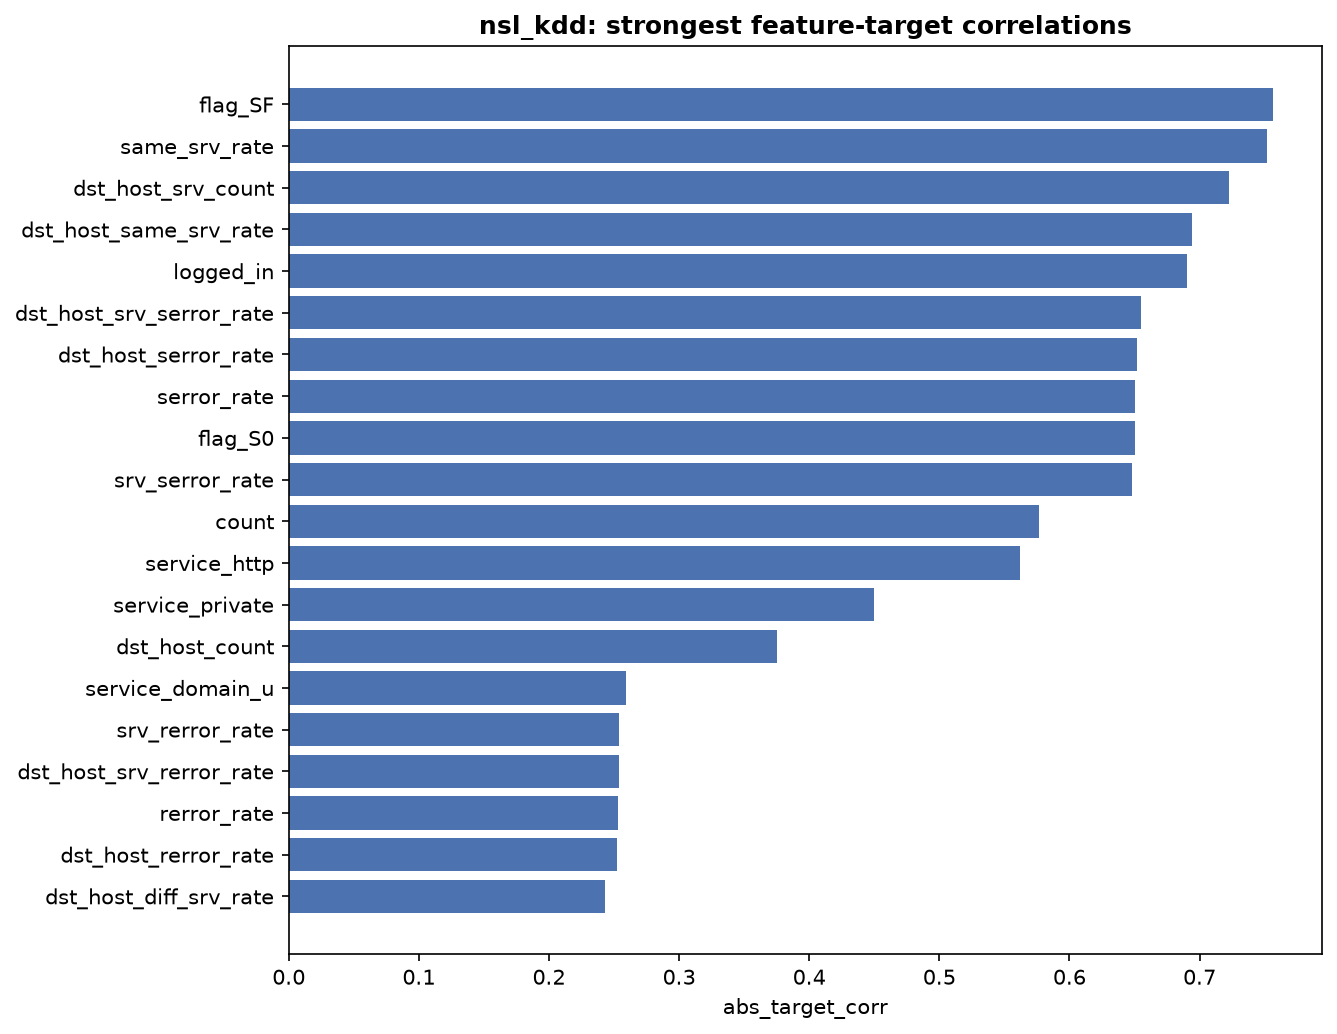

### feature_outliers_nsl_kdd.png

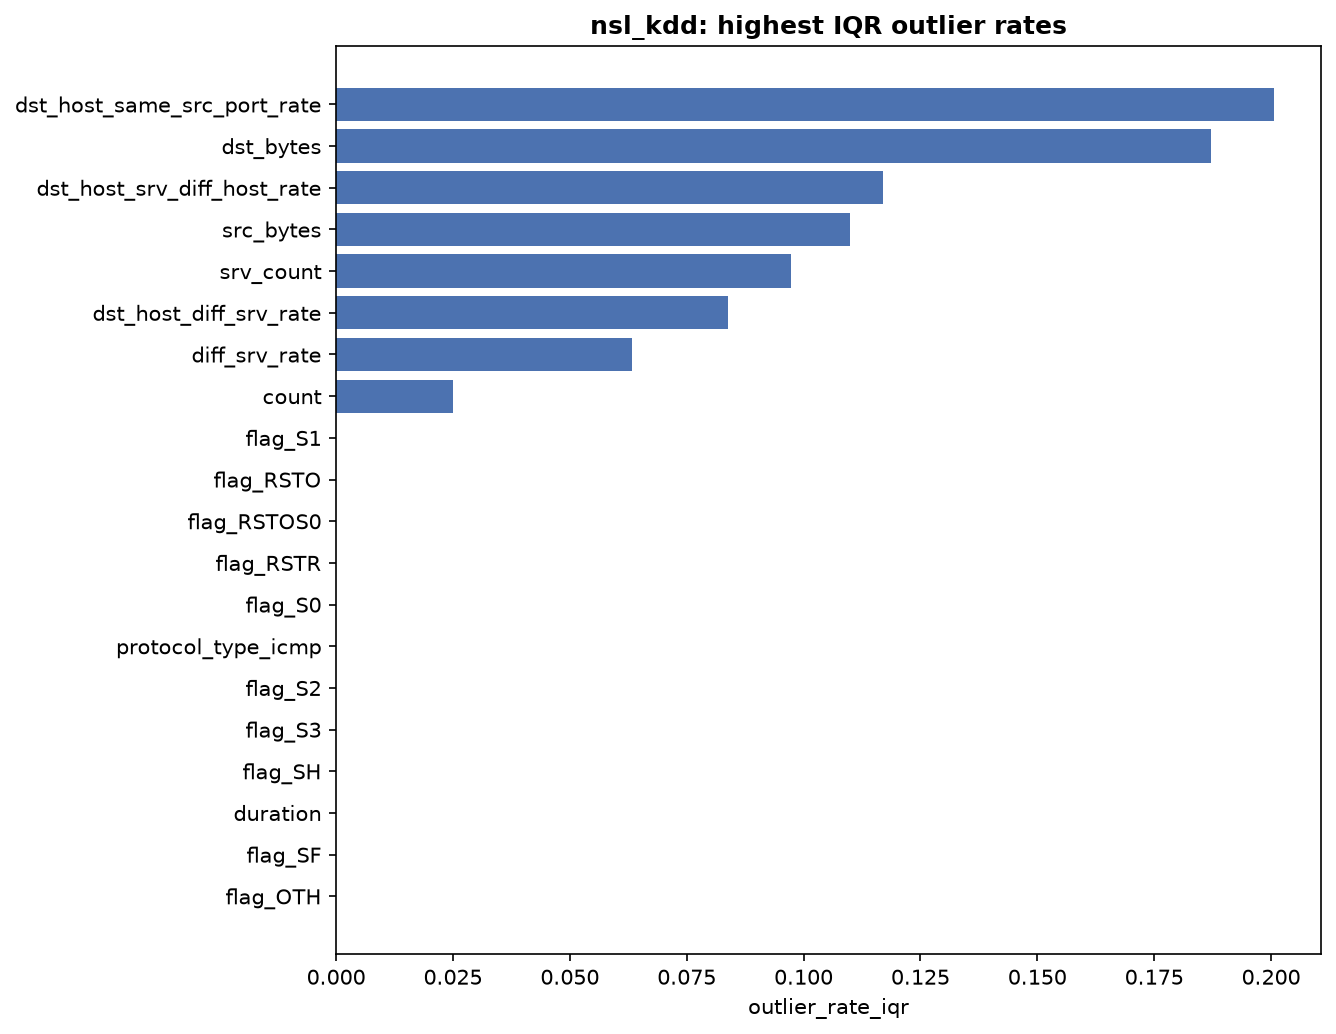

In [7]:
for image_path in [
    REPO / "results" / "figures" / "feature_corr_nsl_kdd.png",
    REPO / "results" / "figures" / "feature_outliers_nsl_kdd.png",
]:
    if image_path.exists():
        display(Markdown(f"### {image_path.name}"))
        display(Image(filename=str(image_path)))


### 6. Attribute-By-Attribute Comparison

This is the deeper audit table. It compares every original NSL-KDD attribute against the binary target and against model attribution signals.

Read this as a referee, not as a blind feature-deletion list: high importance can mean real signal, benchmark artifact, or deployment risk. Low importance can mean genuinely weak signal, redundancy, or a model family that does not use the feature well.

In [8]:
attribute_table = pd.read_csv(REPO / "results" / "attribute_comparison_nsl_kdd.csv")
encoded_table = pd.read_csv(REPO / "results" / "encoded_feature_comparison_nsl_kdd.csv")

print("raw attributes:", len(attribute_table))
print("encoded features:", len(encoded_table))

display(Markdown("### Full raw attribute comparison, ranked"))
display(attribute_table)

view_cols = [
    "attribute",
    "raw_type",
    "encoded_feature_count",
    "class_separation",
    "target_corr_max_abs",
    "outlier_rate_max",
    "redundant_pair_count",
    "logreg_importance_sum",
    "rf_importance_sum",
    "mutual_info_sum",
    "importance_consensus",
    "audit_flags",
    "engineering_recommendation",
]

display(Markdown("### Highest consensus attributes"))
display(attribute_table.sort_values("importance_consensus", ascending=False)[view_cols].head(20))

display(Markdown("### Largest train/test distribution shift"))
display(
    attribute_table.sort_values("train_test_shift_std", ascending=False)[
        ["attribute", "raw_type", "train_mean", "test_mean", "train_std", "test_std", "train_test_shift_std", "audit_flags"]
    ].head(20)
)

display(Markdown("### Highest outlier-rate attributes"))
display(
    attribute_table.sort_values("outlier_rate_max", ascending=False)[
        ["attribute", "raw_type", "outlier_rate_max", "importance_consensus", "audit_flags", "engineering_recommendation"]
    ].head(20)
)

display(Markdown("### Most important encoded one-hot/scaled features"))
display(encoded_table.head(40))


raw attributes: 41
encoded features: 122


### Full raw attribute comparison, ranked

,dataset,attribute,raw_type,encoded_feature_count,train_missing_rate,test_missing_rate,train_unique,test_unique,unseen_test_categories,train_mean,test_mean,train_std,test_std,train_test_shift_std,normal_mean,attack_mean,class_separation,max_category_attack_rate,target_corr_max_abs,target_corr_mean_abs,outlier_rate_max,outlier_rate_mean,redundant_pair_count,logreg_importance_sum,logreg_importance_max,rf_importance_sum,rf_importance_max,mutual_info_sum,mutual_info_max,importance_consensus,rank_by_consensus,audit_flags,engineering_recommendation
0,nsl_kdd,service,categorical,70,0.0,0.0,70,64,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.860010,1.000000,0.562312,0.071729,0.000000,0.000000,0,80.281928,7.428958,0.089466,0.033022,0.575758,0.187184,0.838274,1,strong_target_signal,Keep one-hot encoded; compare category-level attack rates before collapsing.
1,nsl_kdd,src_bytes,numeric,1,0.0,0.0,3341,1149,0,45566.743000,10395.450231,5.870308e+06,472775.945112,0.005991,13133.279331,82820.141327,0.011455,NaN,0.005921,0.005921,0.109865,0.109865,0,0.134901,0.134901,0.150034,0.150034,0.562524,0.562524,0.633028,2,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
2,nsl_kdd,flag,categorical,11,0.0,0.0,11,11,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.774897,1.000000,0.756286,0.181282,0.000000,0.000000,4,21.033031,4.623350,0.083082,0.054424,0.626835,0.332170,0.605249,3,highly_redundant; strong_target_signal,Keep one-hot encoded; compare category-level attack rates before collapsing.
3,nsl_kdd,dst_bytes,numeric,1,0.0,0.0,9326,3650,0,19779.114421,2056.018808,4.021253e+06,21218.826985,0.004407,4329.685223,37524.482159,0.007964,NaN,0.004118,0.004118,0.187175,0.187175,0,1.563797,1.563797,0.115659,0.115659,0.435948,0.435948,0.495281,4,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
4,nsl_kdd,same_srv_rate,numeric,1,0.0,0.0,101,75,0,0.660928,0.740345,4.396211e-01,0.412487,0.180649,0.969360,0.306659,2.225238,NaN,0.751913,0.751913,0.000000,0.000000,0,0.801211,0.801211,0.040785,0.040785,0.361691,0.361691,0.286277,5,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
5,nsl_kdd,dst_host_srv_count,numeric,1,0.0,0.0,256,256,0,115.653005,140.750532,1.107023e+02,111.781493,0.226712,190.285761,29.929081,2.132382,NaN,0.722535,0.722535,0.000000,0.000000,0,1.850970,1.850970,0.042598,0.042598,0.331948,0.331948,0.278847,6,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
6,nsl_kdd,dst_host_same_srv_rate,numeric,1,0.0,0.0,101,101,0,0.521242,0.608722,4.489476e-01,0.435678,0.194856,0.811875,0.187417,1.931757,NaN,0.693803,0.693803,0.000000,0.000000,0,0.856965,0.856965,0.043831,0.043831,0.303882,0.303882,0.262535,7,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
7,nsl_kdd,diff_srv_rate,numeric,1,0.0,0.0,95,99,0,0.063053,0.094074,1.803137e-01,0.259132,0.172040,0.028788,0.102410,0.412173,NaN,0.203660,0.203660,0.063339,0.063339,0,0.190894,0.190894,0.029721,0.029721,0.358971,0.358971,0.257714,8,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.
8,nsl_kdd,dst_host_serror_rate,numeric,1,0.0,0.0,101,99,0,0.284452,0.097814,4.447823e-01,0.273133,0.419618,0.013930,0.595177,1.666853,NaN,0.651842,0.651842,0.000000,0.000000,4,0.087111,0.087111,0.044133,0.044133,0.282419,0.282419,0.248595,9,highly_redundant; strong_target_signal,Keep for tree baselines; test feature selection or regularization to reduce ...
9,nsl_kdd,count,numeric,1,0.0,0.0,512,495,0,84.107555,79.028345,1.145082e+02,128.536397,0.044357,22.517945,154.849991,1.380498,NaN,0.576444,0.576444,0.025061,0.025061,0,2.067201,2.067201,0.042719,0.042719,0.264324,0.264324,0.244054,10,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.


### Highest consensus attributes

,attribute,raw_type,encoded_feature_count,class_separation,target_corr_max_abs,outlier_rate_max,redundant_pair_count,logreg_importance_sum,rf_importance_sum,mutual_info_sum,importance_consensus,audit_flags,engineering_recommendation
0,service,categorical,70,0.860010,0.562312,0.000000,0,80.281928,0.089466,0.575758,0.838274,strong_target_signal,Keep one-hot encoded; compare category-level attack rates before collapsing.
1,src_bytes,numeric,1,0.011455,0.005921,0.109865,0,0.134901,0.150034,0.562524,0.633028,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
2,flag,categorical,11,0.774897,0.756286,0.000000,4,21.033031,0.083082,0.626835,0.605249,highly_redundant; strong_target_signal,Keep one-hot encoded; compare category-level attack rates before collapsing.
3,dst_bytes,numeric,1,0.007964,0.004118,0.187175,0,1.563797,0.115659,0.435948,0.495281,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
4,same_srv_rate,numeric,1,2.225238,0.751913,0.000000,0,0.801211,0.040785,0.361691,0.286277,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
5,dst_host_srv_count,numeric,1,2.132382,0.722535,0.000000,0,1.850970,0.042598,0.331948,0.278847,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
6,dst_host_same_srv_rate,numeric,1,1.931757,0.693803,0.000000,0,0.856965,0.043831,0.303882,0.262535,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
7,diff_srv_rate,numeric,1,0.412173,0.203660,0.063339,0,0.190894,0.029721,0.358971,0.257714,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.
8,dst_host_serror_rate,numeric,1,1.666853,0.651842,0.000000,4,0.087111,0.044133,0.282419,0.248595,highly_redundant; strong_target_signal,Keep for tree baselines; test feature selection or regularization to reduce ...
9,count,numeric,1,1.380498,0.576444,0.025061,0,2.067201,0.042719,0.264324,0.244054,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.


...

,attribute,raw_type,train_mean,test_mean,train_std,test_std,train_test_shift_std,audit_flags
31,num_failed_logins,numeric,0.001222,0.021647,0.045239,0.150324,0.451471,ordinary
8,dst_host_serror_rate,numeric,0.284452,0.097814,0.444782,0.273133,0.419618,highly_redundant; strong_target_signal
10,serror_rate,numeric,0.284485,0.102924,0.446454,0.295360,0.406673,highly_redundant; strong_target_signal
12,dst_host_srv_serror_rate,numeric,0.278485,0.099426,0.445667,0.281860,0.401776,highly_redundant; strong_target_signal
13,srv_serror_rate,numeric,0.282485,0.103635,0.447021,0.298325,0.400094,highly_redundant; strong_target_signal
21,dst_host_rerror_rate,numeric,0.118832,0.233385,0.306556,0.387220,0.373677,ordinary
23,rerror_rate,numeric,0.119958,0.238463,0.320434,0.416108,0.369825,highly_redundant
24,srv_rerror_rate,numeric,0.121183,0.235179,0.323646,0.416206,0.352223,highly_redundant
22,dst_host_srv_rerror_rate,numeric,0.120240,0.226683,0.319458,0.400866,0.333199,highly_redundant
5,dst_host_srv_count,numeric,115.653005,140.750532,110.702301,111.781493,0.226712,strong_target_signal


### Highest outlier-rate attributes

,attribute,raw_type,outlier_rate_max,importance_consensus,audit_flags,engineering_recommendation
15,dst_host_same_src_port_rate,numeric,0.200654,0.146600,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
3,dst_bytes,numeric,0.187175,0.495281,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
16,dst_host_srv_diff_host_rate,numeric,0.116930,0.145083,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
1,src_bytes,numeric,0.109865,0.633028,many_iqr_outliers,"Keep, but prefer robust scaling/winsorization ablation because extreme value..."
20,srv_count,numeric,0.097283,0.067141,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.
11,dst_host_diff_srv_rate,numeric,0.083748,0.211274,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.
7,diff_srv_rate,numeric,0.063339,0.257714,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.
9,count,numeric,0.025061,0.244054,strong_target_signal,Keep in the baseline; use ablation/permutation importance before changing it.
31,num_failed_logins,numeric,0.000000,0.004287,ordinary,"Candidate for pruning in a compact model, but verify with ablation before re..."
26,hot,numeric,0.000000,0.024860,ordinary,Keep in the baseline; use ablation/permutation importance before changing it.


### Most important encoded one-hot/scaled features

,dataset,encoded_feature,attribute,target_corr,abs_target_corr,outlier_rate_iqr,logreg_importance,rf_importance,mutual_info,importance_consensus
0,nsl_kdd,src_bytes,src_bytes,0.005921,0.005921,0.109865,0.134901,1.500336e-01,0.562524,0.672720
1,nsl_kdd,dst_bytes,dst_bytes,0.004118,0.004118,0.187175,1.563797,1.156594e-01,0.435948,0.585459
2,nsl_kdd,flag_SF,flag,-0.756286,0.756286,0.000000,1.874941,5.442430e-02,0.332170,0.401877
3,nsl_kdd,flag_S0,flag,0.650206,0.650206,0.000000,4.220737,2.306709e-02,0.260493,0.394991
4,nsl_kdd,dst_host_srv_count,dst_host_srv_count,-0.722535,0.722535,0.000000,1.850970,4.259806e-02,0.331948,0.374395
5,nsl_kdd,count,count,0.576444,0.576444,0.025061,2.067201,4.271921e-02,0.264324,0.344294
6,nsl_kdd,same_srv_rate,same_srv_rate,-0.751913,0.751913,0.000000,0.801211,4.078520e-02,0.361691,0.340890
7,nsl_kdd,service_IRC,service,-0.035563,0.035563,0.000000,7.428958,2.324854e-04,0.001687,0.334849
8,nsl_kdd,srv_serror_rate,srv_serror_rate,0.648289,0.648289,0.000000,2.778461,2.401974e-02,0.260509,0.332402
9,nsl_kdd,dst_host_same_srv_rate,dst_host_same_srv_rate,-0.693803,0.693803,0.000000,0.856965,4.383106e-02,0.303882,0.315903


### 7. Row-Level Outlier Datapoints

Feature-level outlier rates tell us which columns are spiky. This section answers the datapoint question: which exact rows are outliers, what labels/families do they have, and which numeric features caused the outlier flag?

The IQR fences are fitted on KDDTrain+ only and then applied to both train and KDDTest+, so test outliers are judged against the training distribution.

row summaries: 148517
feature-frequency rows: 56


### Top outlier datapoints

,split,row_index,label,attack_family,outlier_feature_count,max_abs_robust_z,top_outlier_features
23954,train,23954,normal,normal,12,20252.000000,"duration, num_root, num_compromised, dst_bytes, src_bytes, num_access_files,..."
17927,train,17927,normal,normal,12,16754.000000,"duration, dst_bytes, num_compromised, num_root, dst_host_srv_diff_host_rate,..."
47186,train,47186,normal,normal,12,13368.000000,"duration, dst_bytes, num_file_creations, src_bytes, dst_host_srv_diff_host_r..."
137738,test,11765,multihop,R2L,12,1776.000000,"duration, dst_bytes, dst_host_srv_diff_host_rate, num_root, hot, num_comprom..."
128394,test,2421,xterm,U2R,12,293.000000,"duration, dst_bytes, num_root, num_compromised, src_bytes, dst_host_diff_srv..."
146528,test,20555,buffer_overflow,U2R,12,192.000000,"duration, num_compromised, num_root, dst_bytes, src_bytes, dst_host_srv_diff..."
129594,test,3621,xterm,U2R,12,184.000000,"duration, dst_host_srv_diff_host_rate, num_root, dst_host_same_src_port_rate..."
63940,train,63940,normal,normal,11,15183.000000,"duration, num_root, num_compromised, dst_bytes, dst_host_diff_srv_rate, num_..."
31166,train,31166,normal,normal,11,14943.000000,"duration, num_root, num_compromised, dst_bytes, dst_host_srv_diff_host_rate,..."
108454,train,108454,normal,normal,11,14538.000000,"duration, dst_bytes, num_compromised, num_root, src_bytes, num_file_creation..."


### Features most often responsible for row-level outliers

,split,feature,outlier_rows,mean_abs_robust_z
0,test,dst_host_rerror_rate,9175,0.573453
1,test,dst_host_srv_rerror_rate,7251,0.704777
2,test,rerror_rate,5763,0.932832
3,test,srv_rerror_rate,5648,0.938716
4,test,srv_diff_host_rate,4975,0.444583
5,test,dst_bytes,4327,19.552908
6,test,dst_host_same_src_port_rate,3610,12.918513
7,test,duration,3526,1399.307714
8,test,src_bytes,2737,307.149597
9,test,srv_count,2271,14.419969


### nsl_outlier_score_distribution.png

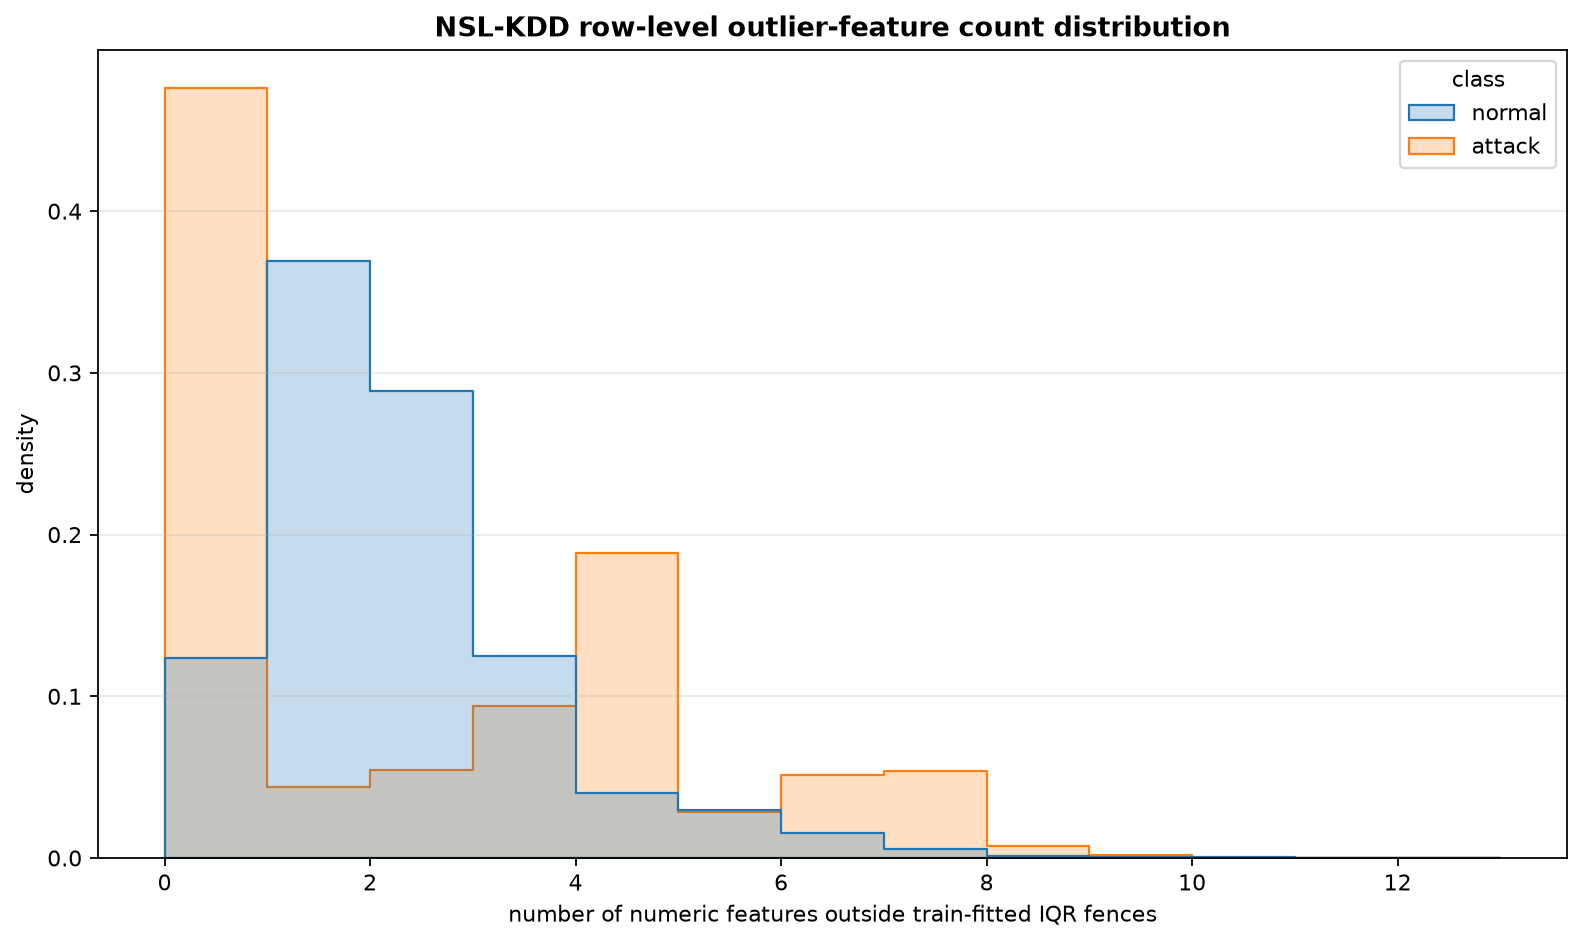

### nsl_top_outlier_datapoints.png

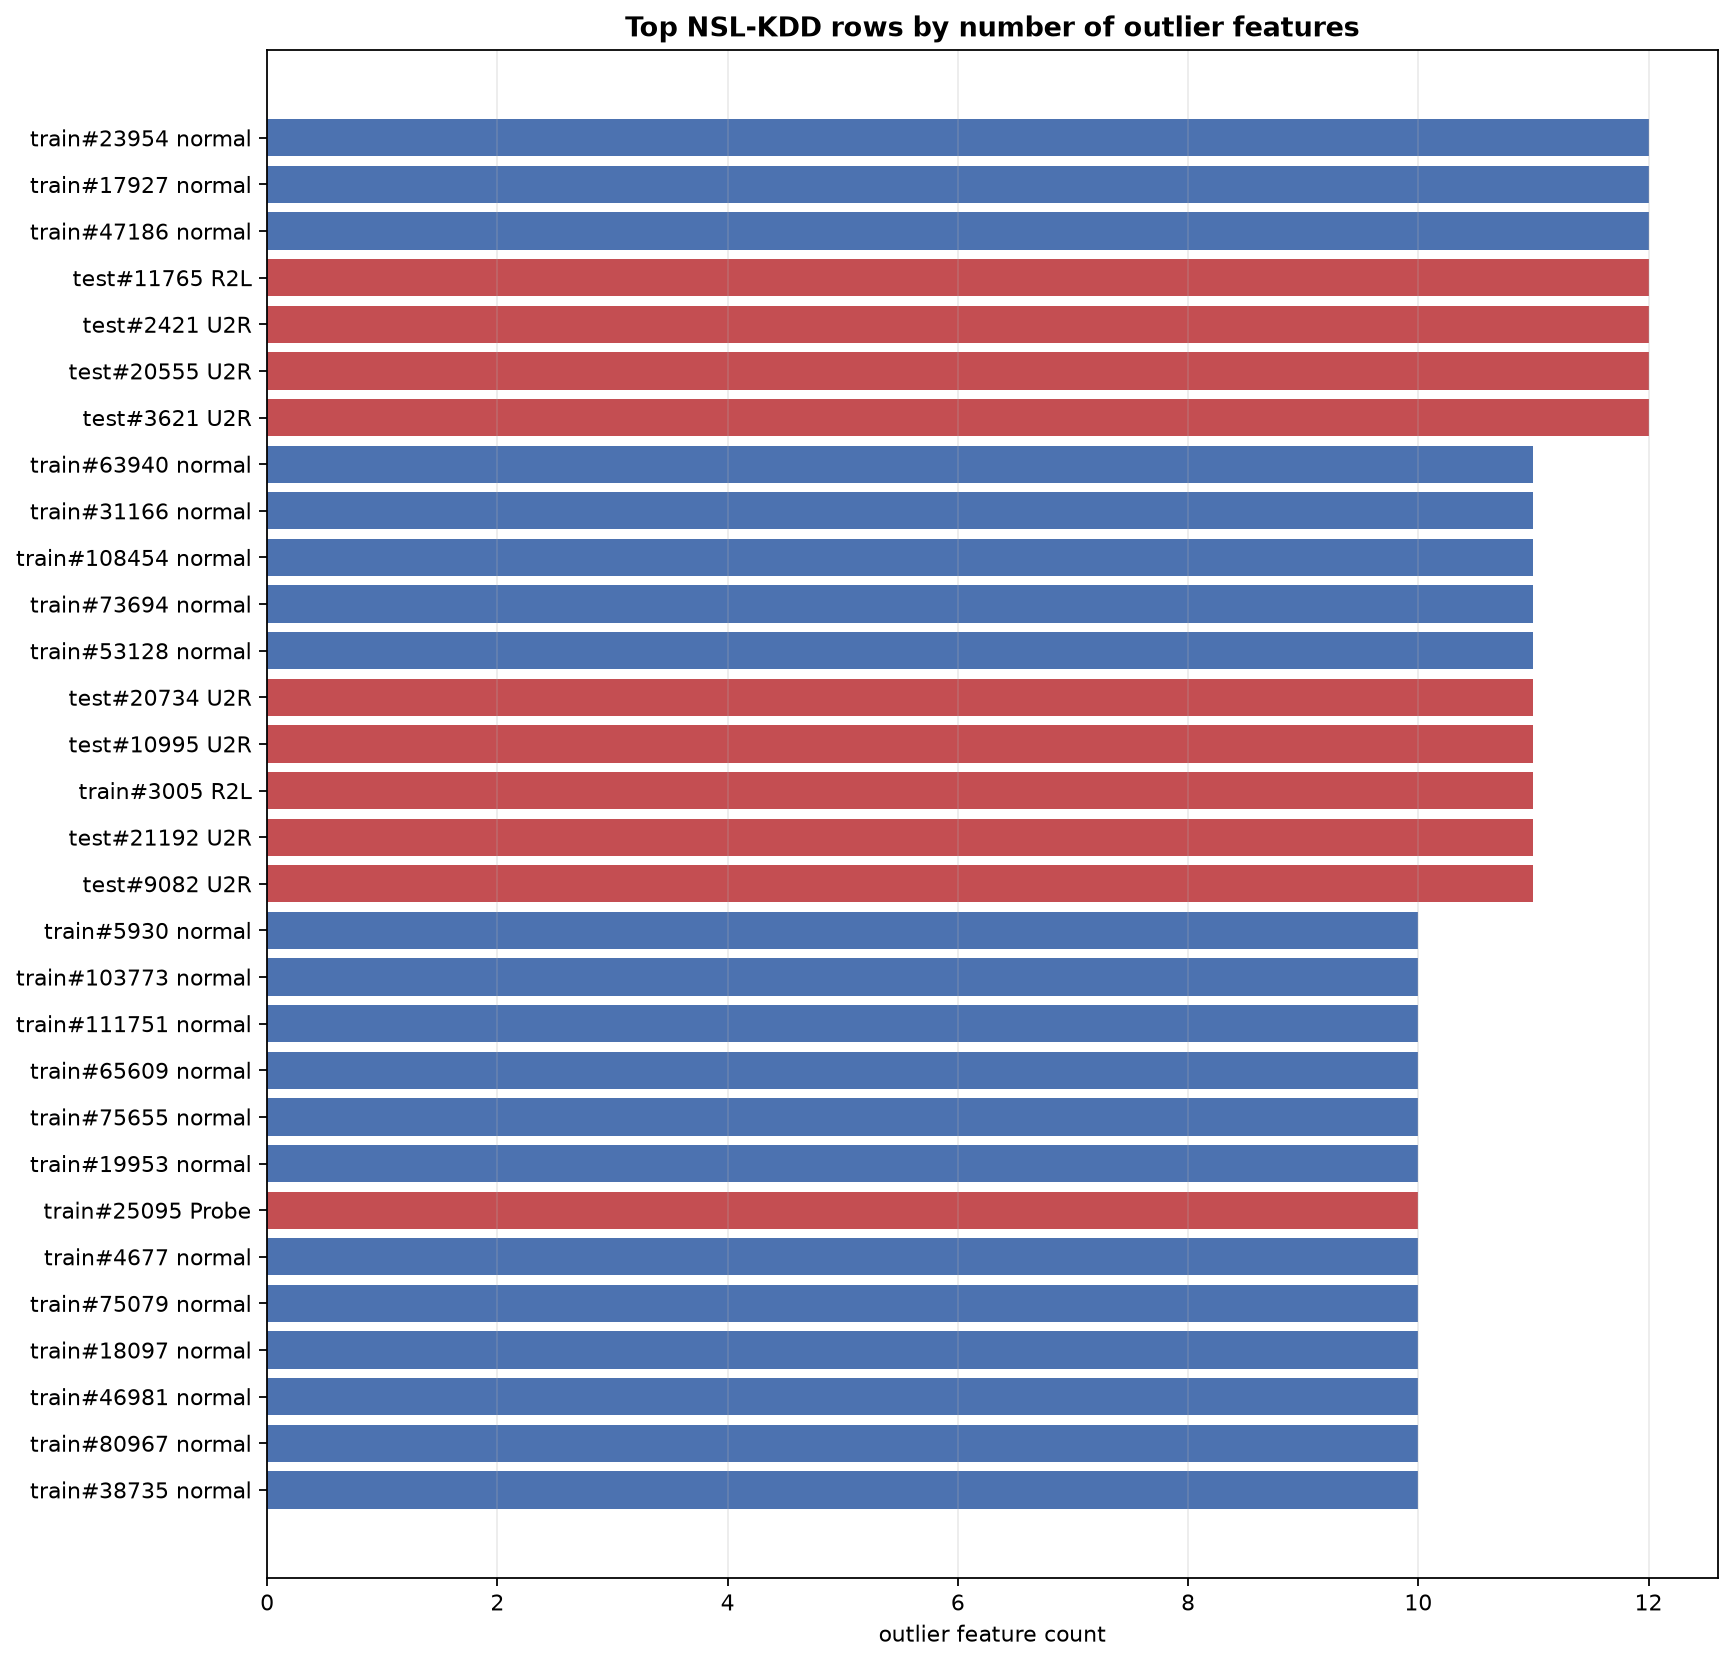

### nsl_top_outlier_feature_heatmap.png

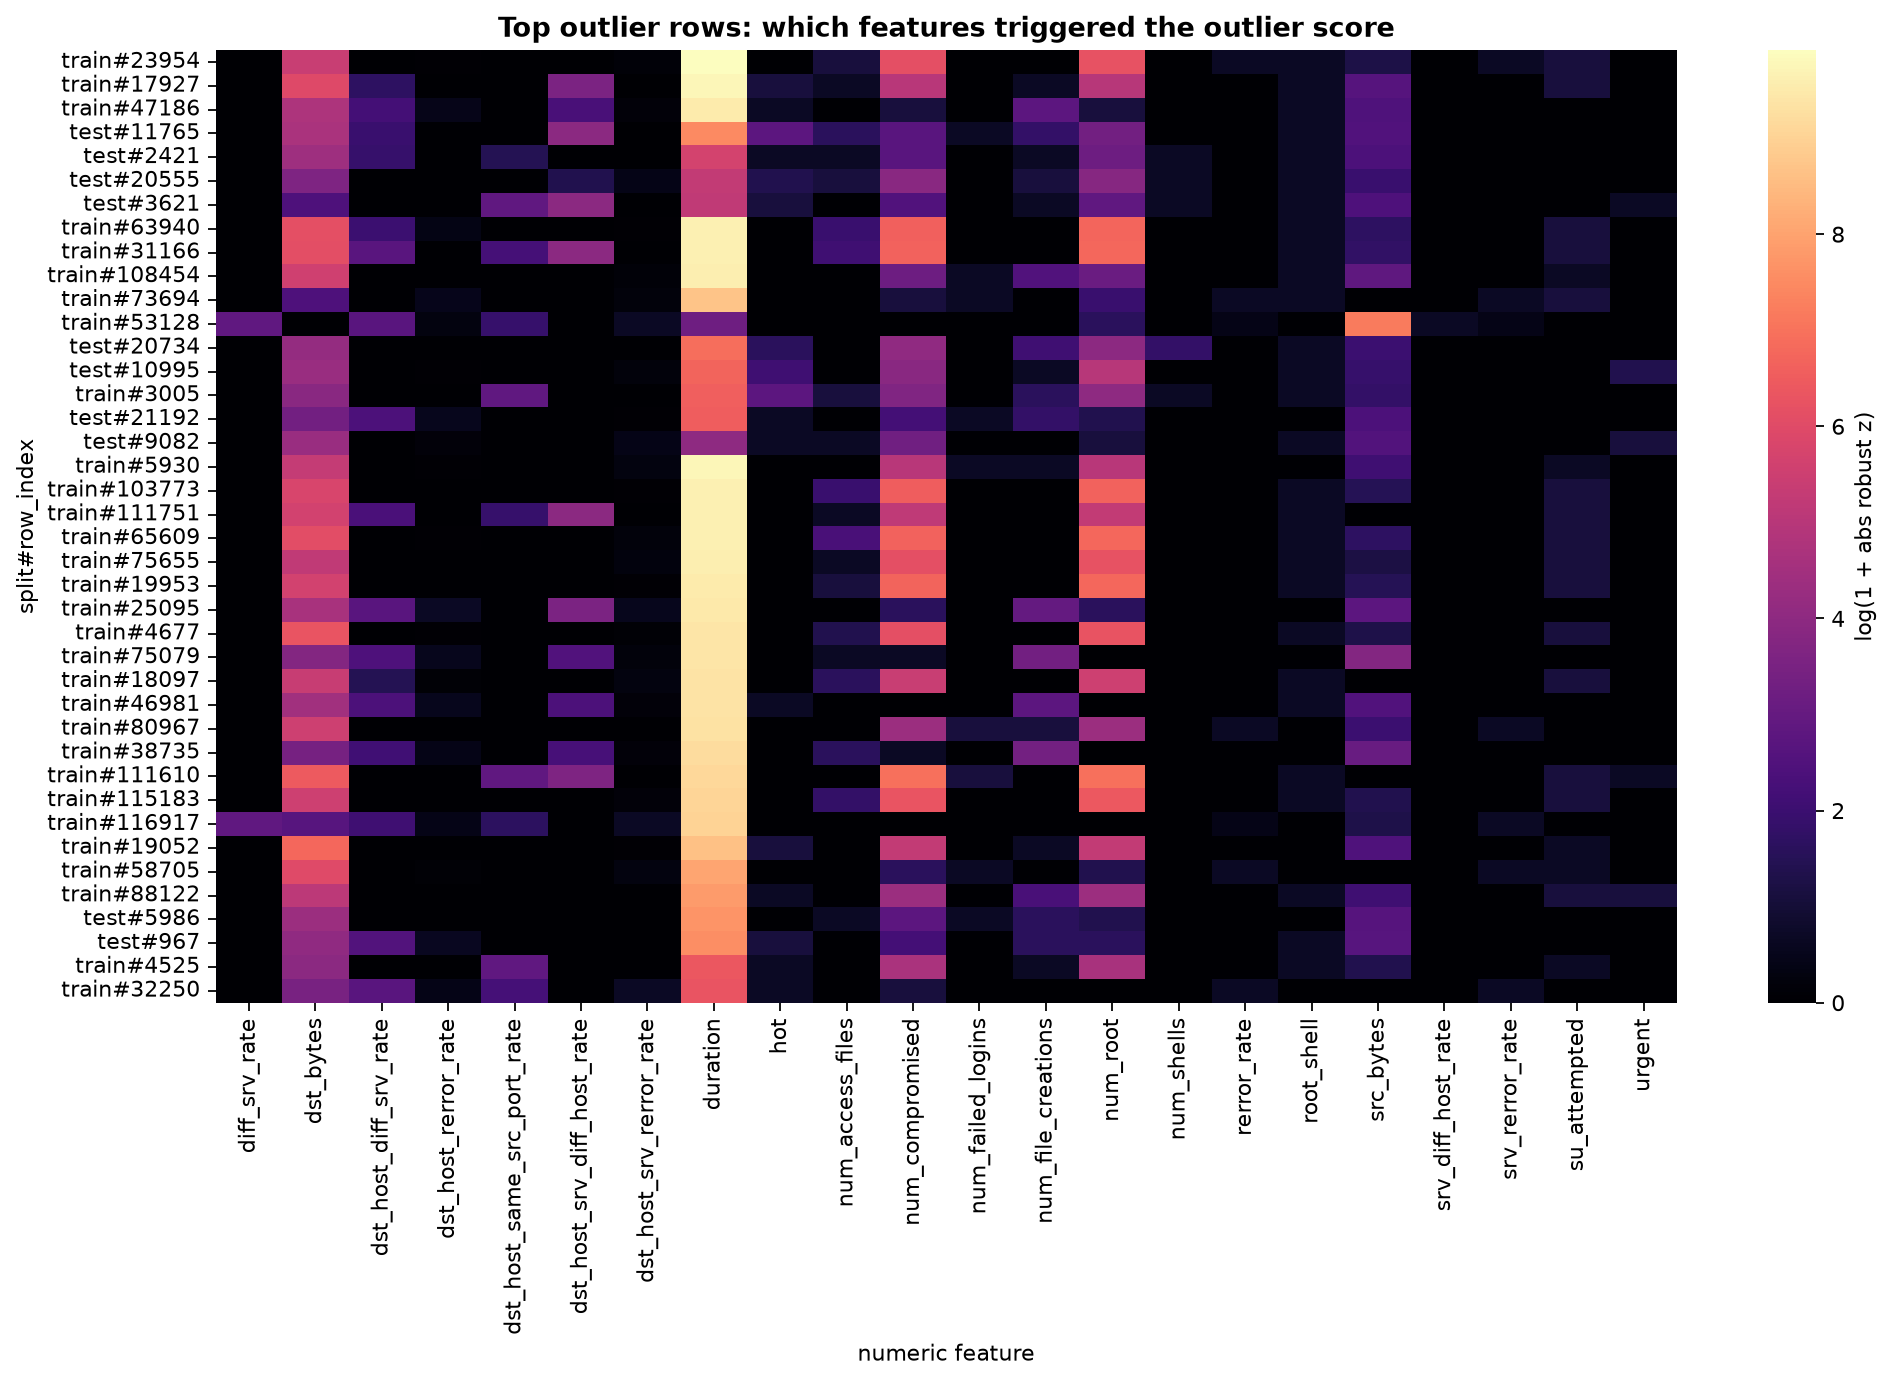

### nsl_outlier_feature_frequency.png

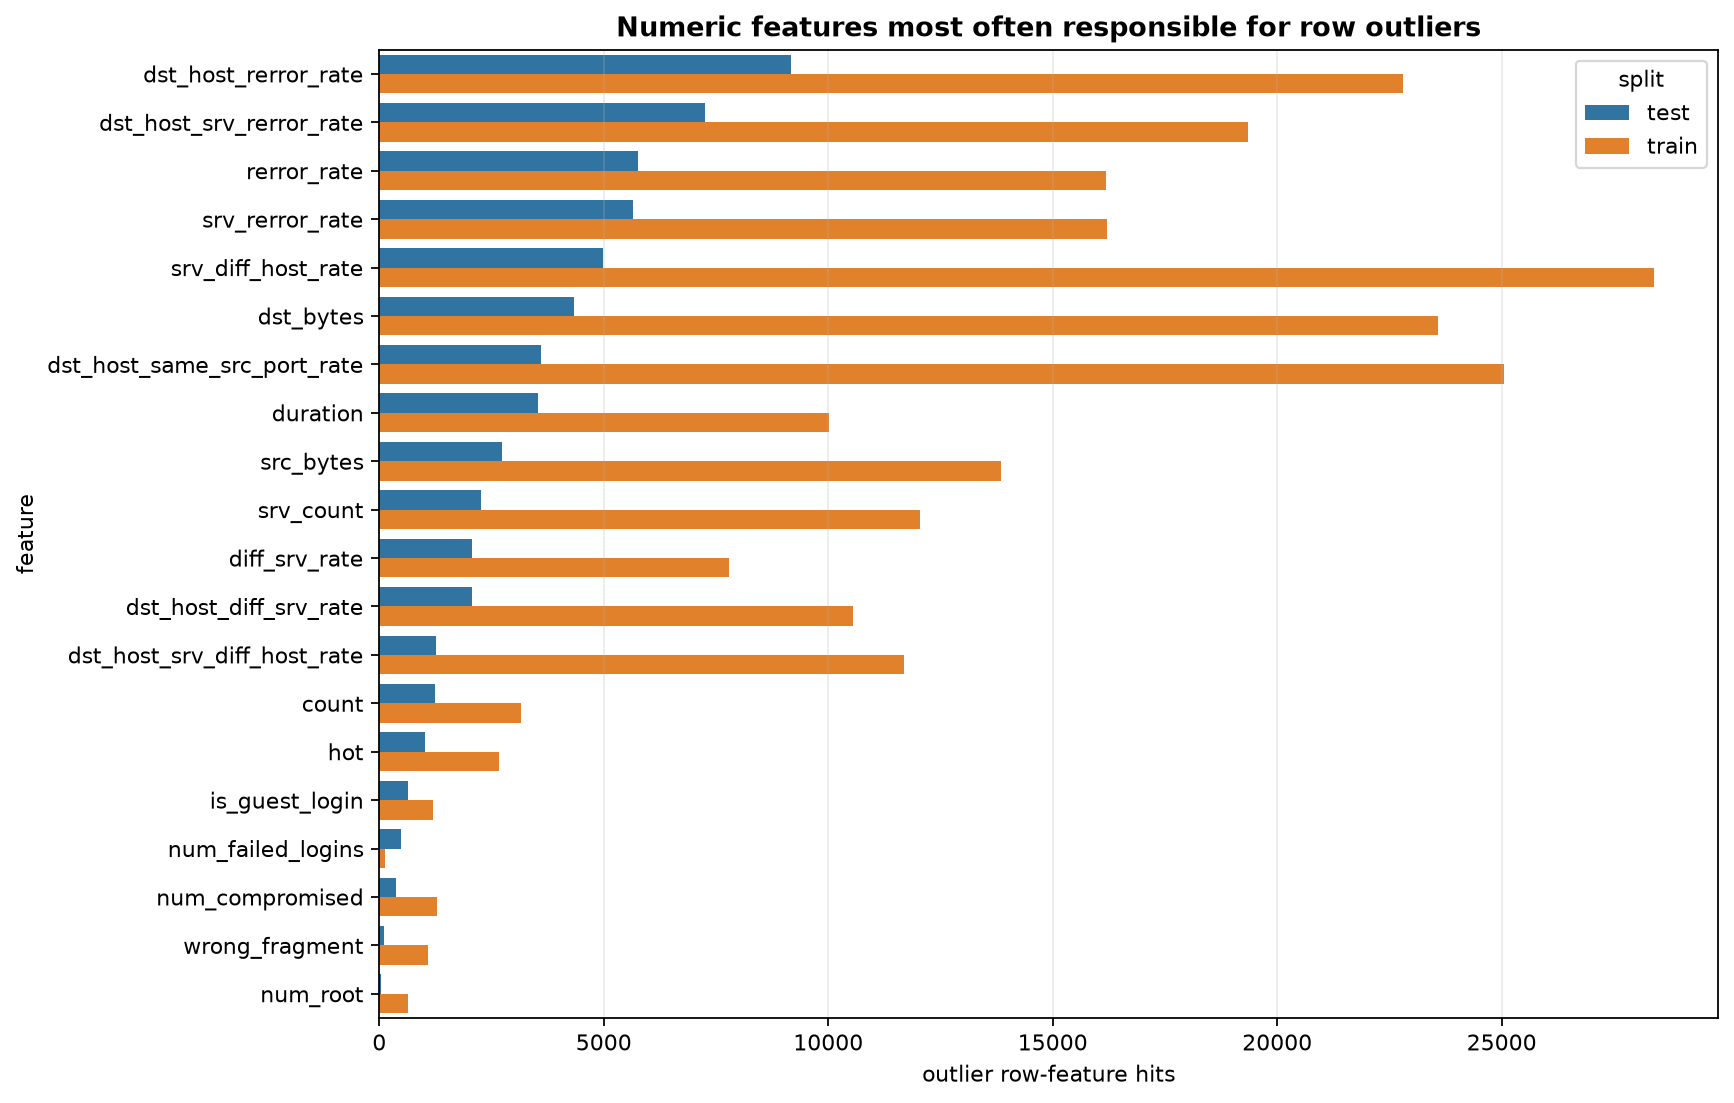

In [9]:
outlier_rows = pd.read_csv(REPO / "results" / "nsl_kdd_outlier_datapoints.csv")
outlier_features = pd.read_csv(REPO / "results" / "nsl_kdd_outlier_feature_frequency.csv")

print("row summaries:", len(outlier_rows))
print("feature-frequency rows:", len(outlier_features))

display(Markdown("### Top outlier datapoints"))
display(
    outlier_rows.sort_values(["outlier_feature_count", "max_abs_robust_z"], ascending=False)
    [["split", "row_index", "label", "attack_family", "outlier_feature_count", "max_abs_robust_z", "top_outlier_features"]]
    .head(25)
)

display(Markdown("### Features most often responsible for row-level outliers"))
display(outlier_features.groupby("split").head(15))

for image_path in [
    REPO / "results" / "figures" / "nsl_outlier_score_distribution.png",
    REPO / "results" / "figures" / "nsl_top_outlier_datapoints.png",
    REPO / "results" / "figures" / "nsl_top_outlier_feature_heatmap.png",
    REPO / "results" / "figures" / "nsl_outlier_feature_frequency.png",
]:
    if image_path.exists():
        display(Markdown(f"### {image_path.name}"))
        display(Image(filename=str(image_path)))


### 8. NSL-KDD First-Dataset Learning Lab

This section answers the criticism directly: the requested learning methods are applied to the first dataset, NSL-KDD, before being generalized elsewhere.

The table separates what is applied from what is intentionally not applied. CNN and pooling are not run on isolated tabular rows because that would impose a fake locality structure; they need packet sequences, temporal windows, byte streams, traffic matrices, or another justified representation.

In [10]:
nsl_lab = pd.read_csv(REPO / "results" / "nsl_kdd_learning_lab.csv")
nsl_groups = pd.read_csv(REPO / "results" / "nsl_kdd_feature_group_ablation.csv")
nsl_ci = pd.read_csv(REPO / "results" / "nsl_kdd_bootstrap_ci.csv")
nsl_matrix = pd.read_csv(REPO / "results" / "nsl_kdd_concept_application_matrix.csv")

print("NSL-KDD method rows:", len(nsl_lab))
print("NSL-KDD feature-group rows:", len(nsl_groups))

display(Markdown("### Concept application matrix for the first dataset"))
display_big_table(
    nsl_matrix,
    ["concept", "status", "first_dataset_interpretation"],
    max_rows=20,
)

display(Markdown("### Training methods applied to NSL-KDD"))
method_cols = [
    "level",
    "family",
    "method",
    "variant",
    "macro_f1",
    "attack_recall",
    "precision_attack",
    "normal_recall",
    "mcc",
    "fp_per_10k_benign",
    "fn_per_10k_attack",
]
display_big_table(
    nsl_lab.sort_values("macro_f1", ascending=False),
    method_cols,
    max_rows=25,
)

display(Markdown("### Feature groups applied to NSL-KDD"))
group_cols = [
    "variant",
    "encoded_feature_count",
    "macro_f1",
    "attack_recall",
    "precision_attack",
    "normal_recall",
    "mcc",
    "fp_per_10k_benign",
    "fn_per_10k_attack",
]
display_big_table(
    nsl_groups.sort_values("macro_f1", ascending=False),
    group_cols,
    max_rows=20,
)

display(Markdown("### Bootstrap confidence intervals on KDDTest+"))
display_big_table(nsl_ci, max_rows=20)


NSL-KDD method rows: 17
NSL-KDD feature-group rows: 8


### Concept application matrix for the first dataset

,concept,status,first_dataset_interpretation
0,Level 0 data validation,APPLIED,"schema, labels, class balance, missing/unique/constant checks"
1,Naive baselines,APPLIED,most-frequent and stratified dummy baselines
2,Logistic Regression variants,APPLIED,"unweighted, balanced, L1, L2, Elastic Net, threshold variants"
3,Feature-group ablation,APPLIED,"numeric, categorical, byte-volume, host, connection-rate, content groups"
4,Regularization,APPLIED,"C=1 vs C=0.1, L1, L2, Elastic Net"
5,Tree and ensemble baselines,APPLIED,"DecisionTree, RandomForest, ExtraTrees, HistGradientBoosting"
6,Online-capable linear model,APPLIED,SGDClassifier; true drift is not claimed
7,Bootstrap confidence intervals,APPLIED,test-set bootstrap intervals for selected models
8,Benign-only security anomaly,APPLIED,OneClassSVM and normal-only autoencoder
9,Artificial neuron foundations,APPLIED,activation/loss/update demo


### Training methods applied to NSL-KDD

,level,family,method,variant,macro_f1,attack_recall,precision_attack,normal_recall,mcc,fp_per_10k_benign,fn_per_10k_attack
9,Level 4,tree_family,DecisionTree,balanced_depth18,0.806694,0.721188,0.922364,0.919782,0.638657,802.183091,2788.124367
16,Security ML,benign_only_anomaly,AutoEncoder,normal_only_q0.95,0.801845,0.710278,0.924067,0.922871,0.631998,771.290289,2897.218110
12,Level 4,boosting,HistGradientBoosting,default,0.794779,0.660796,0.969697,0.972711,0.643790,272.886417,3392.036157
5,Level 1,threshold_policy,LogReg,validation_F2_attack_weighted_0.15,0.786015,0.693758,0.908748,0.907939,0.601068,920.605499,3062.417206
15,Security ML,benign_only_anomaly,OneClassSVM,normal_only_nu0.05,0.782983,0.679420,0.918079,0.919885,0.601029,801.153331,3205.797553
14,Level 4,instance_based,KNN,k5_train_cap,0.767028,0.613964,0.966511,0.971888,0.603797,281.124498,3860.360009
4,Level 1,threshold_policy,LogReg,validation_F1_threshold_0.35,0.762251,0.643419,0.913789,0.919782,0.569083,802.183091,3565.806904
13,Level 4,linear_online,SGDClassifier,log_loss_balanced,0.761896,0.640536,0.916490,0.922871,0.570002,771.290289,3594.638822
10,Level 4,tree_family,RandomForest,balanced_depth18,0.761890,0.604769,0.966862,0.972608,0.597091,273.916178,3952.310450
11,Level 4,tree_family,ExtraTrees,balanced_depth18,0.757762,0.630250,0.919613,0.927196,0.565908,728.040367,3697.498636


### Feature groups applied to NSL-KDD

,variant,encoded_feature_count,macro_f1,attack_recall,precision_attack,normal_recall,mcc,fp_per_10k_benign,fn_per_10k_attack
0,dst_host_behavior,10,0.788844,0.666641,0.947083,0.950777,0.623901,492.225312,3333.593080
1,categorical_one_hot,83,0.781710,0.691109,0.902605,0.901452,0.591740,985.480383,3088.911400
2,protocol_service_flag,83,0.781710,0.691109,0.902605,0.901452,0.591740,985.480383,3088.911400
3,connection_count_rates,9,0.765688,0.636017,0.931310,0.938008,0.583111,619.915560,3639.834801
4,content_login_shell,13,0.756198,0.760929,0.805029,0.756462,0.513896,2435.382556,2390.711447
5,all_features,121,0.754035,0.625341,0.916933,0.925136,0.559330,748.635568,3746.590821
6,numeric_only,38,0.747940,0.611782,0.919752,0.929461,0.552552,705.385645,3882.178758
7,byte_volume,2,0.360116,0.058521,0.851474,0.986510,0.115007,134.898569,9414.789995


### Bootstrap confidence intervals on KDDTest+

,dataset,model,metric,mean,ci_low,ci_high,n_bootstrap
0,nsl_kdd,LogReg_l2_balanced,macro_f1,0.752018,0.746179,0.757474,300
1,nsl_kdd,LogReg_l2_balanced,attack_recall,0.622341,0.613625,0.629750,300
2,nsl_kdd,ExtraTrees_balanced,macro_f1,0.774447,0.769061,0.779918,300
3,nsl_kdd,ExtraTrees_balanced,attack_recall,0.627650,0.618948,0.636103,300


### 9. Neural Foundations: One Neuron Before Neural Networks

This stage explains the atomic piece of neural learning:

```text
weighted sum + bias → activation → prediction → loss → gradient → weight update
```

You should understand this before trusting any MLP/CNN/RNN result.

### Single-neuron forward/backward step

,linear_z,prediction,loss,grad_w,grad_b,w_after,bias_after
0,0.42,0.603483,0.505037,"[-0.3172134, 0.4758201, -0.1586067]",-0.396517,"[0.33172134, -0.24758201, 0.11586067]",-0.060348


### Activation-function sample values

,x,linear,sigmoid,sigmoid_derivative,tanh,tanh_derivative,relu,relu_derivative,leaky_relu,elu,gelu
0,-5.000,-5.000,0.006693,0.006648,-0.999909,0.000182,0.0,0.0,-0.05000,-0.993262,-2.291796e-07
1,-4.975,-4.975,0.006861,0.006814,-0.999905,0.000191,0.0,0.0,-0.04975,-0.993091,-2.711061e-07
2,-4.950,-4.950,0.007034,0.006984,-0.999900,0.000201,0.0,0.0,-0.04950,-0.992917,-3.202679e-07
3,-4.925,-4.925,0.007210,0.007158,-0.999895,0.000211,0.0,0.0,-0.04925,-0.992737,-3.778342e-07
4,-4.900,-4.900,0.007392,0.007337,-0.999889,0.000222,0.0,0.0,-0.04900,-0.992553,-4.451492e-07
5,-4.875,-4.875,0.007577,0.007520,-0.999883,0.000233,0.0,0.0,-0.04875,-0.992365,-5.237562e-07
6,-4.850,-4.850,0.007768,0.007707,-0.999877,0.000245,0.0,0.0,-0.04850,-0.992172,-6.154246e-07
7,-4.825,-4.825,0.007963,0.007899,-0.999871,0.000258,0.0,0.0,-0.04825,-0.991973,-7.221798e-07


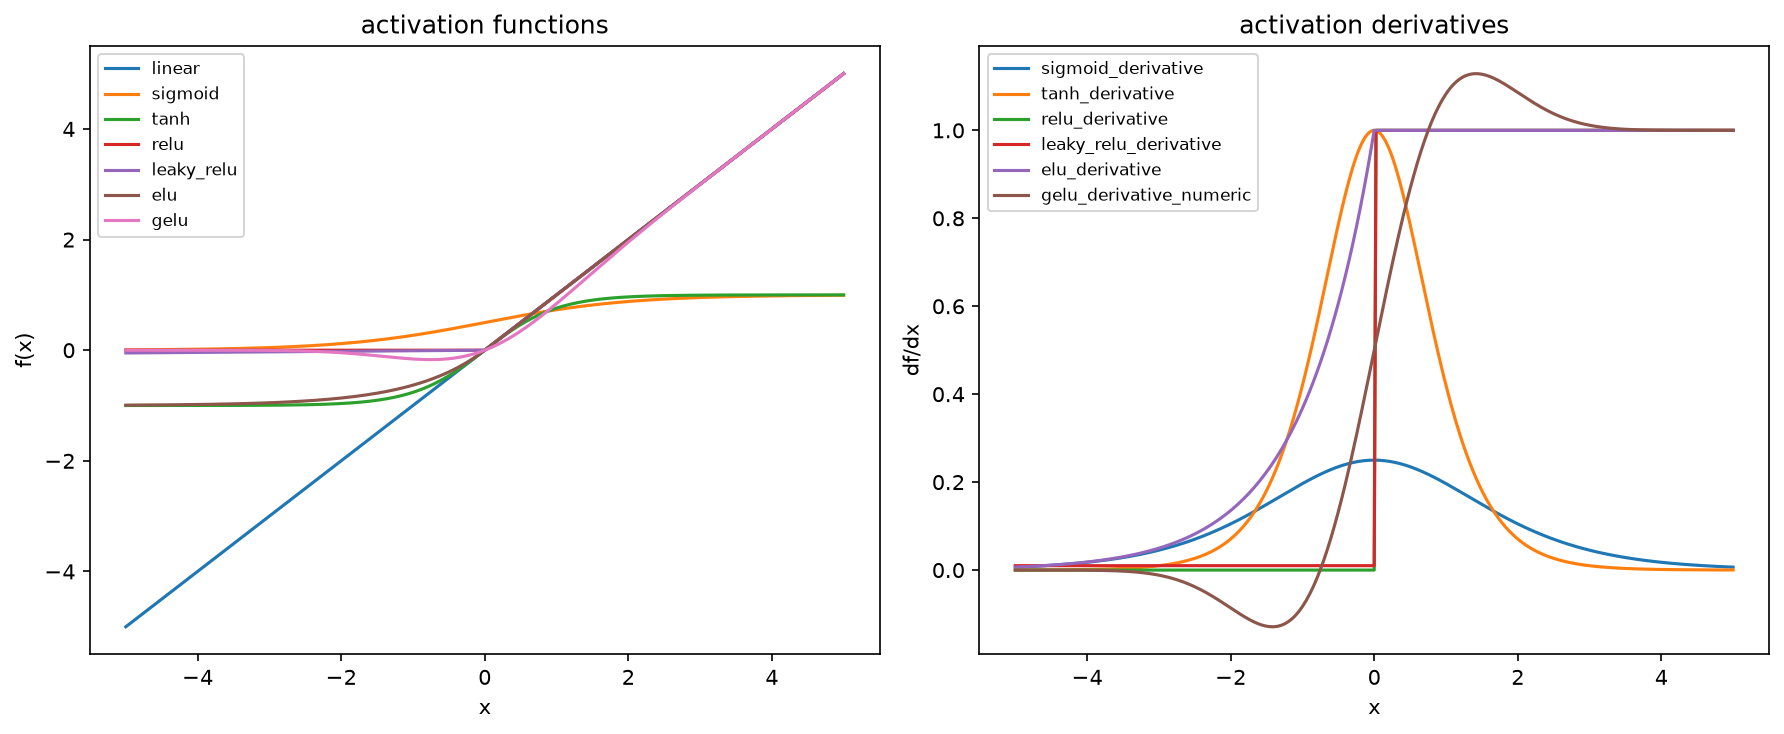

In [11]:
neuron_demo = pd.read_csv(REPO / "results" / "single_neuron_demo.csv")
activation_df = pd.read_csv(REPO / "results" / "activation_functions.csv")

display(Markdown("### Single-neuron forward/backward step"))
display_big_table(neuron_demo, max_rows=10)

display(Markdown("### Activation-function sample values"))
activation_cols = [
    "x",
    "linear",
    "sigmoid",
    "sigmoid_derivative",
    "tanh",
    "tanh_derivative",
    "relu",
    "relu_derivative",
    "leaky_relu",
    "elu",
    "gelu",
]
display_big_table(activation_df.head(8), activation_cols, max_rows=8)

activation_plot = REPO / "results" / "figures" / "neural_foundations_activation_functions.png"
if activation_plot.exists():
    display(Image(filename=str(activation_plot)))


### 10. Neural Ablation: What Changes When We Change One Thing?

This stage runs a bounded MLP ablation. It changes one major factor at a time:

- activation function,
- dropout,
- batch normalization,
- depth/width,
- weighted loss,
- focal loss,
- label smoothing.

This is how we avoid random model accumulation. A bigger/deeper model is not automatically better.

,config,activation,hidden,dropout,normalization,weighted_loss,focal_loss,label_smoothing,param_count,epochs_ran,macro_f1,attack_recall,mcc,train_seconds
8,label_smoothing_0.05,relu,"(64,)",0.0,none,False,False,0.05,8002,14,0.775930,0.662355,0.592898,0.787296
7,focal_loss,relu,"(64,)",0.0,none,False,True,0.00,8002,14,0.769872,0.651991,0.583574,0.704506
4,batchnorm,relu,"(64,)",0.0,batchnorm,False,False,0.00,8130,14,0.767646,0.646848,0.581029,0.733931
5,deeper_2x128_64,relu,"(128, 64)",0.0,none,False,False,0.00,24130,14,0.766063,0.643809,0.578840,0.764969
6,weighted_cross_entropy,relu,"(64,)",0.0,none,True,False,0.00,8002,14,0.760912,0.636952,0.569758,0.715763
1,activation_tanh,tanh,"(64,)",0.0,none,False,False,0.00,8002,14,0.757296,0.630874,0.564244,0.799456
0,baseline_relu_1x64,relu,"(64,)",0.0,none,False,False,0.00,8002,14,0.753246,0.623315,0.558624,0.718836
3,dropout_0.30,relu,"(64,)",0.3,none,False,False,0.00,8002,14,0.752105,0.621133,0.557088,0.692886
2,activation_gelu,gelu,"(64,)",0.0,none,False,False,0.00,8002,14,0.750312,0.619029,0.553753,0.805129


### neural_ablation_train_loss.png

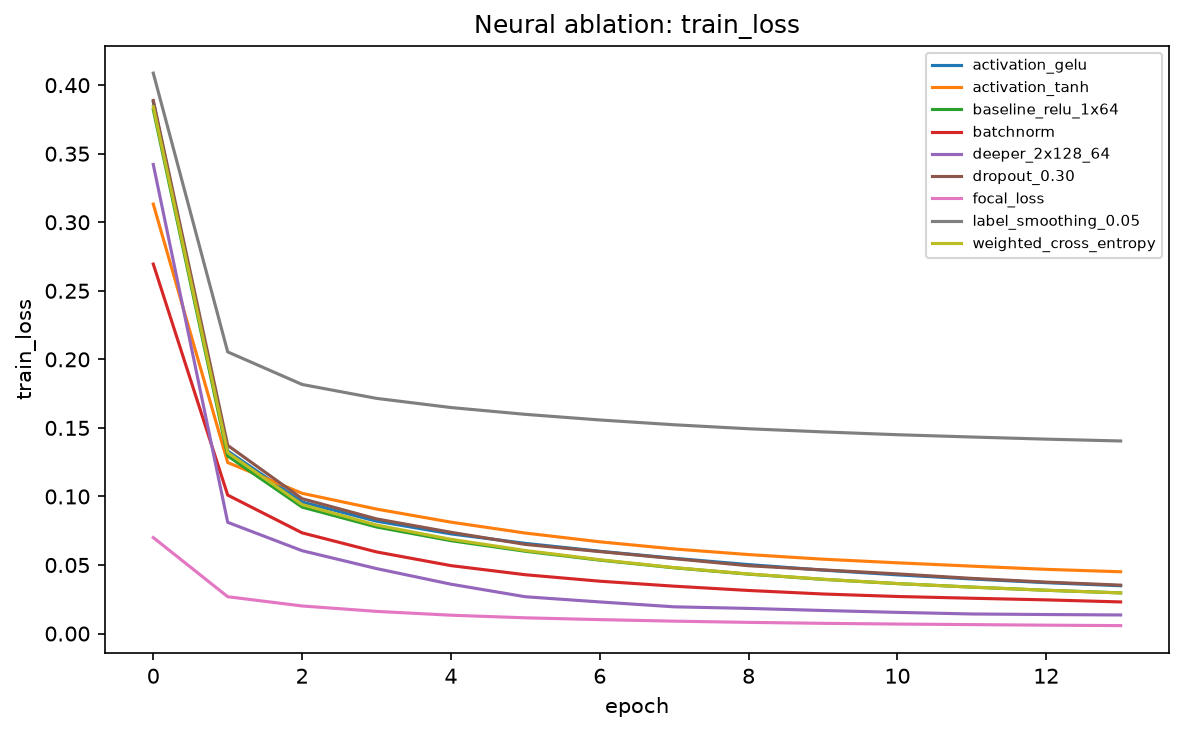

### neural_ablation_val_macro_f1.png

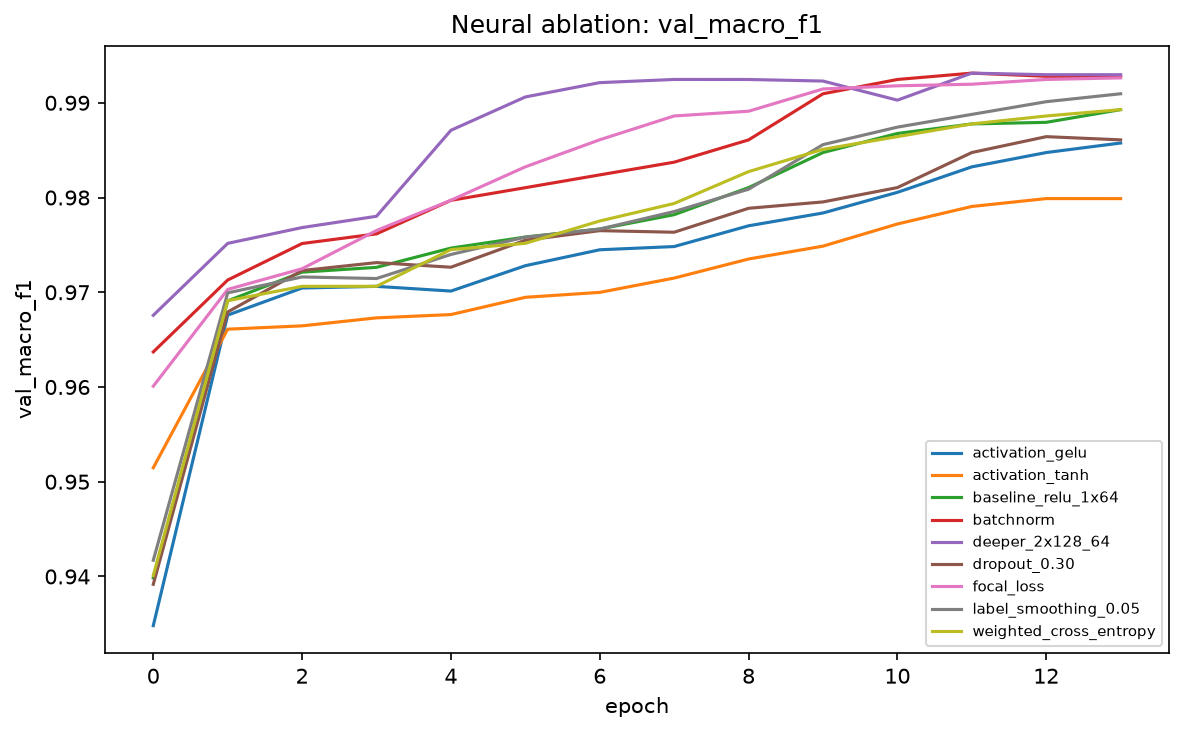

### neural_ablation_grad_norm.png

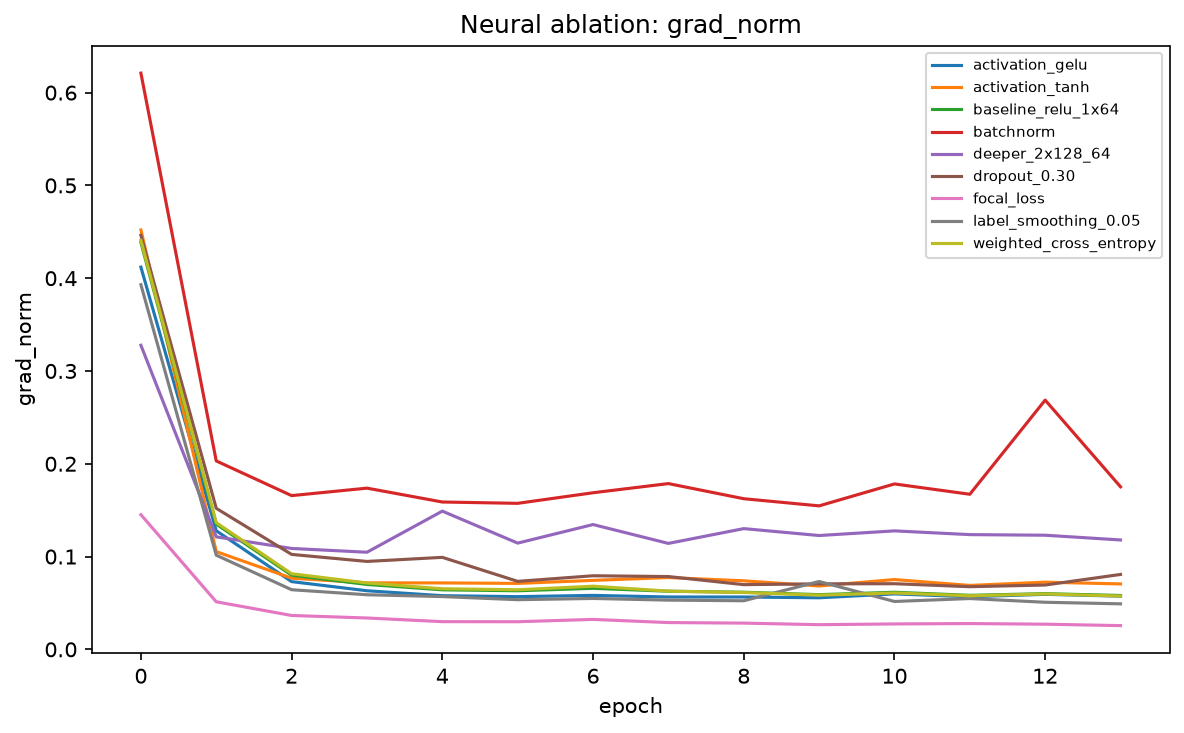

In [12]:
neural = pd.read_csv(REPO / "results" / "neural_ablation.csv")
curves = pd.read_csv(REPO / "results" / "neural_ablation_curves.csv")

display(neural.sort_values("macro_f1", ascending=False)[[
    "config", "activation", "hidden", "dropout", "normalization", "weighted_loss", "focal_loss", "label_smoothing",
    "param_count", "epochs_ran", "macro_f1", "attack_recall", "mcc", "train_seconds"
]])

for image_path in [
    REPO / "results" / "figures" / "neural_ablation_train_loss.png",
    REPO / "results" / "figures" / "neural_ablation_val_macro_f1.png",
    REPO / "results" / "figures" / "neural_ablation_grad_norm.png",
]:
    if image_path.exists():
        display(Markdown(f"### {image_path.name}"))
        display(Image(filename=str(image_path)))


### 11. Thresholds and SOC Workload

A classifier’s default threshold is usually `0.50`, but intrusion detection often cares more about missed attacks than false alarms.

This stage asks:

- What happens if we tune the threshold on validation data?
- How many false alerts would that create in a SOC-like daily workload?
- Does the best macro-F1 model still make operational sense?

In [13]:
thresholds = pd.read_csv(REPO / "results" / "threshold_ablation.csv")
soc = pd.read_csv(REPO / "results" / "soc_simulation.csv")

display(Markdown("### Threshold ablation"))
display(thresholds.sort_values("macro_f1", ascending=False))

display(Markdown("### SOC simulation"))
display(soc.sort_values("total_alerts_per_day"))


### Threshold ablation

,model,threshold_name,threshold,selection_rule,accuracy,macro_f1,weighted_f1,normal_recall,attack_precision,attack_recall,fp_per_10k_benign
11,HistGB_balanced,validation_F2_attack_recall_weighted,0.24,validation F-beta beta=2.0,0.823057,0.823031,0.822734,0.969416,0.968531,0.712304,305.838740
10,HistGB_balanced,validation_F1,0.32,validation F-beta beta=1.0,0.816004,0.815927,0.815405,0.970961,0.969510,0.698745,290.392339
8,ExtraTrees_balanced,validation_F2_attack_recall_weighted,0.31,validation F-beta beta=2.0,0.812677,0.812602,0.813123,0.919988,0.923554,0.731474,800.123571
9,HistGB_balanced,default_0.50,0.50,fixed,0.797152,0.796826,0.795699,0.971785,0.968892,0.665004,282.154258
6,ExtraTrees_balanced,default_0.50,0.50,fixed,0.788103,0.787582,0.786124,0.972299,0.968699,0.648718,277.005458
7,ExtraTrees_balanced,validation_F1,0.51,validation F-beta beta=1.0,0.785885,0.785308,0.783766,0.972402,0.968626,0.644744,275.975698
2,LogReg,validation_F2_attack_recall_weighted,0.13,validation F-beta beta=2.0,0.783046,0.783044,0.783136,0.905365,0.906033,0.690485,946.349501
5,LogReg_balanced,validation_F2_attack_recall_weighted,0.17,validation F-beta beta=2.0,0.779099,0.779096,0.778990,0.908351,0.907609,0.681290,916.486459
4,LogReg_balanced,validation_F1,0.37,validation F-beta beta=1.0,0.759626,0.759364,0.758266,0.919988,0.913359,0.638276,800.123571
1,LogReg,validation_F1,0.37,validation F-beta beta=1.0,0.758783,0.758494,0.757337,0.920914,0.914007,0.636094,790.855731


### SOC simulation

,model,threshold_name,threshold,macro_f1,normal_recall,attack_recall,false_alerts_per_day,true_alerts_per_day,missed_attacks_per_day,total_alerts_per_day,operational_precision
7,ExtraTrees_balanced,validation_F1,0.51,0.785308,0.972402,0.644744,27459.581917,3223.720097,1776.279903,30683.302014,0.105064
6,ExtraTrees_balanced,default_0.50,0.50,0.787582,0.972299,0.648718,27562.043044,3243.590743,1756.409257,30805.633787,0.105292
9,HistGB_balanced,default_0.50,0.50,0.796826,0.971785,0.665004,28074.348677,3325.021429,1674.978571,31399.370106,0.105895
10,HistGB_balanced,validation_F1,0.32,0.815927,0.970961,0.698745,28894.037689,3493.727110,1506.272890,32387.764799,0.107872
11,HistGB_balanced,validation_F2_attack_recall_weighted,0.24,0.823031,0.969416,0.712304,30430.954588,3561.521078,1438.478922,33992.475666,0.104774
0,LogReg,default_0.50,0.50,0.753519,0.926063,0.623782,73567.088868,3118.912180,1881.087820,76686.001048,0.040671
3,LogReg_balanced,default_0.50,0.50,0.753899,0.925136,0.625107,74489.239007,3125.535728,1874.464272,77614.774736,0.040270
1,LogReg,validation_F1,0.37,0.758494,0.920914,0.636094,78690.145196,3180.472220,1819.527780,81870.617416,0.038848
4,LogReg_balanced,validation_F1,0.37,0.759364,0.919988,0.638276,79612.295335,3191.381594,1808.618406,82803.676930,0.038542
8,ExtraTrees_balanced,validation_F2_attack_recall_weighted,0.31,0.812602,0.919988,0.731474,79612.295335,3657.367724,1342.632276,83269.663059,0.043922


### 12. Anomaly Detection: Learn Normal, Flag Deviations

This is a different learning problem from supervised classification.

Supervised models learn labelled attack examples. Anomaly detectors learn normal behaviour and flag unusual rows. That can help with unknown attacks, but it can also create many false positives or miss attacks that resemble normal traffic.

In [14]:
anomaly = pd.read_csv(REPO / "results" / "anomaly_detection.csv")
display(anomaly.sort_values("macro_f1", ascending=False))


,model,normal_quantile,threshold,accuracy,macro_f1,normal_recall,attack_recall,DoS_recall,Probe_recall,R2L_recall,U2R_recall
6,KMeans_distance,0.90,3.185776,0.841909,0.841344,0.907939,0.791943,0.923324,0.971912,0.304333,0.656716
0,IsolationForest,0.90,0.399711,0.831884,0.831389,0.902688,0.778306,0.914611,0.994630,0.250607,0.507463
1,IsolationForest,0.95,0.420097,0.809572,0.809511,0.918855,0.726876,0.878954,0.989674,0.121317,0.373134
2,IsolationForest,0.99,0.482525,0.796797,0.796334,0.980229,0.657991,0.847185,0.850062,0.021490,0.059701
7,KMeans_distance,0.95,3.973234,0.788769,0.788756,0.924416,0.686122,0.776005,0.899215,0.275563,0.656716
3,LocalOutlierFactor,0.90,1.751456,0.739753,0.739732,0.869220,0.641783,0.646247,0.791409,0.503293,0.701493
4,LocalOutlierFactor,0.95,2.585754,0.627617,0.615940,0.930903,0.398114,0.366756,0.430401,0.447487,0.597015
8,KMeans_distance,0.99,8.827641,0.467619,0.375810,0.987952,0.073872,0.002145,0.163982,0.171231,0.611940
5,LocalOutlierFactor,0.99,29.107673,0.438786,0.321289,0.992277,0.019949,0.000402,0.000000,0.084922,0.119403


### 13. Semi-Supervised Learning: What If Labels Are Expensive?

Here we pretend only 1%, 5%, 10%, or 25% of labels are available.

The comparison is:

- Logistic Regression trained only on labelled rows.
- Self-training Logistic Regression using pseudo-labels for unlabelled rows.

Self-training is not guaranteed to help. If early pseudo-labels are wrong, it can amplify its own mistakes.

In [15]:
semi = pd.read_csv(REPO / "results" / "semi_supervised.csv")
display(semi.sort_values(["label_fraction", "method"]))


,method,label_fraction,labelled_rows,accuracy,macro_f1,normal_recall,attack_recall
0,labelled_only_logreg,0.01,1259,0.727555,0.726120,0.928535,0.575469
1,self_training_logreg,0.01,1259,0.722188,0.720463,0.929461,0.565339
2,labelled_only_logreg,0.05,6299,0.747960,0.747438,0.920914,0.617081
3,self_training_logreg,0.05,6299,0.737225,0.736383,0.921326,0.597912
4,labelled_only_logreg,0.10,12597,0.754658,0.754244,0.923592,0.626821
5,self_training_logreg,0.10,12597,0.746851,0.746241,0.923798,0.612951
6,labelled_only_logreg,0.25,31494,0.753992,0.753545,0.924622,0.624873
7,self_training_logreg,0.25,31494,0.752351,0.751868,0.924519,0.622068


### 14. Method Suitability: Why We Are Not Blindly Running CNN/RNN/GAN/DRL Yet

The project has a deep-learning taxonomy, but not every model is valid for every data representation.

NSL-KDD is isolated tabular rows. It has no real packet sequence, host timeline, or traffic matrix. So CNN/RNN/LSTM/GRU would be methodologically suspicious unless we first build a justified sequence/window representation.

In [16]:
taxonomy = (REPO / "docs" / "deep_learning_taxonomy.md").read_text(encoding="utf-8")
# Show the suitability matrix section only.
start = taxonomy.index("## Suitability Matrix")
end = taxonomy.index("## Required Experimental Progression")
display(Markdown(taxonomy[start:end]))


## Suitability Matrix

| Method | NSL-KDD tabular | CICIoT2023 dev tabular | Raw CICIoT sequences | TON_IoT multimodal | CSE-CIC temporal | Role |
| --- | --- | --- | --- | --- | --- | --- |
| Logistic Regression | strong baseline | strong baseline | aggregates only | per modality | aggregates/chronological | scientific baseline |
| MLP | valid | valid | aggregates/windows | per modality/fusion | aggregates/windows | modern tabular baseline |
| CNN | invalid unless feature ordering is justified | invalid unless feature ordering is justified | valid for packet/window sequences | possible for telemetry windows | valid for traffic matrices/windows | representation-dependent |
| RNN/LSTM/GRU | no temporal value on isolated rows | no temporal value on random dev rows | valid for ordered sequences | valid for logs/telemetry timelines | valid for day/time streams | temporal candidate |
| BiLSTM | invalid for real-time row detection | invalid for random dev rows | offline sequence analysis only | offline timeline analysis only | offline chronological analysis only | offline model unless future context is allowed |
| Autoencoder | valid representation/anomaly | valid representation/anomaly | valid | valid | valid | unsupervised representation/anomaly |
| Denoising AE | valid robustness test | valid robustness test | valid masking/noise test | valid missing telemetry test | valid noisy-flow test | robustness representation |
| VAE | educational/probabilistic baseline | possible | possible | possible | possible | probabilistic representation |
| SOM | valid exploratory clustering | valid exploratory clustering | embeddings/windows | embeddings/per modality | embeddings/windows | educational/exploratory |
| RBM/DBN | historical only | historical only | historical only | historical only | historical only | controlled historical comparison |
| GAN | tabular GAN only; train partition only | tabular GAN only; train partition only | sequence GAN possible | modality-specific possible | time-series/tabular possible | augmentation with strict validation |
| CNN-LSTM | invalid without sequences | invalid on random rows | valid for local+long temporal patterns | valid for telemetry sequences | valid for flow windows | hybrid temporal candidate |
| AE-SVM | valid | valid | valid on embeddings | valid on embeddings | valid on embeddings | hybrid representation baseline |
| Transfer learning | source/target must be defined | dev only; not full raw release | valid after schema alignment | valid after modality alignment | valid after feature alignment | domain adaptation candidate |
| Deep RL | not for static classification | not for static classification | only threshold/response environment | triage/response environment | threshold/drift/response environment | sequential decision only |



### 15. Cross-Track Coverage And Comparison Dashboard

This is the part that compares the project as a whole, not one model at a time.

The goal is to answer four referee questions:

- Which row wins if we care about macro-F1?
- Which row wins if we care about catching attacks?
- Which row creates the smallest SOC alert burden?
- Which requested experiment areas are proven, partial, blocked, or still missing?

In [17]:
comparison = pd.read_csv(REPO / "results" / "final_comparison.csv")
coverage = pd.read_csv(REPO / "results" / "experiment_coverage_matrix.csv")

print("comparison rows:", len(comparison))
print("coverage rows:", len(coverage))

display(Markdown("### Coverage Matrix"))
display(coverage)

binary = comparison[(comparison["dataset"] == "nsl_kdd") & (comparison["task"] == "binary")].copy()

summary_cols = [
    "track",
    "method",
    "variant",
    "comparison_family",
    "macro_f1",
    "attack_recall",
    "normal_recall",
    "limitation",
]

display(Markdown("### Best NSL-KDD binary rows by macro-F1"))
display(binary.dropna(subset=["macro_f1"]).sort_values("macro_f1", ascending=False)[summary_cols].head(12))

display(Markdown("### Best NSL-KDD binary rows by attack recall"))
display(binary.dropna(subset=["attack_recall"]).sort_values("attack_recall", ascending=False)[summary_cols].head(12))

family_best = (
    binary.dropna(subset=["macro_f1"])
    .sort_values("macro_f1", ascending=False)
    .groupby("comparison_family")
    .head(1)
    .sort_values("macro_f1", ascending=False)
)
display(Markdown("### Best row inside each experiment family"))
display(family_best[summary_cols])

soc_cols = [
    "method",
    "variant",
    "macro_f1",
    "attack_recall",
    "false_alerts_per_day",
    "missed_attacks_per_day",
    "total_alerts_per_day",
    "operational_precision",
]
display(Markdown("### Lowest SOC alert burden"))
display(
    comparison[comparison["track"] == "soc_simulation"]
    .sort_values("total_alerts_per_day")
    [soc_cols]
    .head(12)
)

status_counts = coverage["status"].value_counts().rename_axis("status").reset_index(name="count")
display(Markdown("### Coverage status counts"))
display(status_counts)


comparison rows: 109
coverage rows: 21


### Coverage Matrix

,experiment_area,status,dataset_scope,evidence,limitation
0,Raw schema and preprocessing,PROVEN,NSL-KDD,"src/data.py, src/preprocess.py",CICIoT raw CSV absent
1,Classical supervised reference,PROVEN,NSL-KDD,results/reference_track.md,single seed for some models
2,Tree/boosting official split,PROVEN,NSL-KDD,results/metrics.md,RF/LightGBM only
3,MLP weighted/unweighted,PROVEN,NSL-KDD,"results/metrics.md, results/stability.md",more ablations now separate
4,Feature engineering/learning,PROVEN,"NSL-KDD, CICIoT2023 dev",results/feature_learning.md,not full raw CICIoT
5,Attribute-by-attribute audit,PROVEN,NSL-KDD,results/attribute_comparison_nsl_kdd.md,binary target attribution only
6,Row-level outlier datapoints,PROVEN,NSL-KDD,results/nsl_kdd_outlier_datapoints.md,numeric IQR outliers only; outlier is not automatically attack
7,First-dataset learning lab,PROVEN,NSL-KDD,results/nsl_kdd_learning_lab.md,CNN/pooling intentionally not applied to isolated tabular rows
8,Neural foundations/ablations,PROVEN,NSL-KDD,"results/neural_foundations.md, results/neural_ablation.md",bounded single-seed MLP ablations
9,Threshold tuning,PROVEN,NSL-KDD,results/threshold_ablation.md,binary only


### Best NSL-KDD binary rows by macro-F1

,track,method,variant,comparison_family,macro_f1,attack_recall,normal_recall,limitation
84,normal_only_anomaly,KMeans_distance,q=0.90,unsupervised_anomaly,0.841344,0.791943,0.907939,normal-only training; threshold from normal quantiles
78,normal_only_anomaly,IsolationForest,q=0.90,unsupervised_anomaly,0.831389,0.778306,0.902688,normal-only training; threshold from normal quantiles
108,soc_simulation,HistGB_balanced,validation_F2_attack_recall_weighted,operational_policy,0.823031,0.712304,0.969416,fixed scenario: 1M flows/day and 0.5% malicious
58,threshold_tuning,HistGB_balanced,validation_F2_attack_recall_weighted,threshold_policy,0.823031,0.712304,0.969416,threshold selected on one validation split
107,soc_simulation,HistGB_balanced,validation_F1,operational_policy,0.815927,0.698745,0.970961,fixed scenario: 1M flows/day and 0.5% malicious
57,threshold_tuning,HistGB_balanced,validation_F1,threshold_policy,0.815927,0.698745,0.970961,threshold selected on one validation split
105,soc_simulation,ExtraTrees_balanced,validation_F2_attack_recall_weighted,operational_policy,0.812602,0.731474,0.919988,fixed scenario: 1M flows/day and 0.5% malicious
55,threshold_tuning,ExtraTrees_balanced,validation_F2_attack_recall_weighted,threshold_policy,0.812602,0.731474,0.919988,threshold selected on one validation split
18,phase4_mlp_weighting,MLP (unweighted),weighted/unweighted,neural_mlp,0.810400,0.688000,NaN,single run; stability reported separately
79,normal_only_anomaly,IsolationForest,q=0.95,unsupervised_anomaly,0.809511,0.726876,0.918855,normal-only training; threshold from normal quantiles


...

,track,method,variant,comparison_family,macro_f1,attack_recall,normal_recall,limitation
84,normal_only_anomaly,KMeans_distance,q=0.90,unsupervised_anomaly,0.841344,0.791943,0.907939,normal-only training; threshold from normal quantiles
108,soc_simulation,HistGB_balanced,validation_F2_attack_recall_weighted,operational_policy,0.823031,0.712304,0.969416,fixed scenario: 1M flows/day and 0.5% malicious
58,threshold_tuning,HistGB_balanced,validation_F2_attack_recall_weighted,threshold_policy,0.823031,0.712304,0.969416,threshold selected on one validation split
18,phase4_mlp_weighting,MLP (unweighted),weighted/unweighted,neural_mlp,0.810400,0.688000,NaN,single run; stability reported separately
31,first_dataset_learning_lab,DecisionTree,balanced_depth18,tree_family,0.806694,0.721188,0.919782,inner KDDTrain+ dev split for fitting/tuning; KDDTest+ final evaluation
38,first_dataset_learning_lab,AutoEncoder,normal_only_q0.95,benign_only_anomaly,0.801845,0.710278,0.922871,inner KDDTrain+ dev split for fitting/tuning; KDDTest+ final evaluation
4,supervised_reference,HistGradientBoosting (balanced),balanced where supported,classical_ml,0.796800,0.665000,NaN,single seed for several reference models
34,first_dataset_learning_lab,HistGradientBoosting,default,boosting,0.794779,0.660796,0.972711,inner KDDTrain+ dev split for fitting/tuning; KDDTest+ final evaluation
39,first_dataset_feature_ablation,LogReg,dst_host_behavior,feature_group_ablation,0.788844,0.666641,0.950777,feature groups tested with balanced Logistic Regression only
14,phase3_tree_boosting,LightGBM,KDDTest+,tree_boosting,0.784500,NaN,NaN,only RF/LightGBM in this artifact


### Lowest SOC alert burden

,method,variant,macro_f1,attack_recall,false_alerts_per_day,missed_attacks_per_day,total_alerts_per_day,operational_precision
104,ExtraTrees_balanced,validation_F1,0.785308,0.644744,27459.581917,1776.279903,30683.302014,0.105064
103,ExtraTrees_balanced,default_0.50,0.787582,0.648718,27562.043044,1756.409257,30805.633787,0.105292
106,HistGB_balanced,default_0.50,0.796826,0.665004,28074.348677,1674.978571,31399.370106,0.105895
107,HistGB_balanced,validation_F1,0.815927,0.698745,28894.037689,1506.272890,32387.764799,0.107872
108,HistGB_balanced,validation_F2_attack_recall_weighted,0.823031,0.712304,30430.954588,1438.478922,33992.475666,0.104774
97,LogReg,default_0.50,0.753519,0.623782,73567.088868,1881.087820,76686.001048,0.040671
100,LogReg_balanced,default_0.50,0.753899,0.625107,74489.239007,1874.464272,77614.774736,0.040270
98,LogReg,validation_F1,0.758494,0.636094,78690.145196,1819.527780,81870.617416,0.038848
101,LogReg_balanced,validation_F1,0.759364,0.638276,79612.295335,1808.618406,82803.676930,0.038542
105,ExtraTrees_balanced,validation_F2_attack_recall_weighted,0.812602,0.731474,79612.295335,1342.632276,83269.663059,0.043922


### Coverage status counts

,status,count
0,PROVEN,13
1,PARTIAL,3
2,BLOCKED,3
3,MISSING,2


### 16. Visual Comparison Dashboard

This is the visual layer for the audit. It exists because the project now has many experiments, and tables alone hide the shape of the results.

Use these plots to compare model families, training choices, feature groups, threshold policies, uncertainty, and attribute importance without pretending that one leaderboard score tells the whole story.

visual metric rows: 25


,source,level,family,method,variant,macro_f1,attack_recall,precision_attack,normal_recall,mcc,fp_per_10k_benign,fn_per_10k_attack
17,feature_group_ablation,Feature groups,feature_ablation,LogReg,dst_host_behavior,0.788844,0.666641,0.947083,0.950777,0.623901,492.225312,3333.593080
18,feature_group_ablation,Feature groups,feature_ablation,LogReg,categorical_one_hot,0.781710,0.691109,0.902605,0.901452,0.591740,985.480383,3088.911400
19,feature_group_ablation,Feature groups,feature_ablation,LogReg,protocol_service_flag,0.781710,0.691109,0.902605,0.901452,0.591740,985.480383,3088.911400
20,feature_group_ablation,Feature groups,feature_ablation,LogReg,connection_count_rates,0.765688,0.636017,0.931310,0.938008,0.583111,619.915560,3639.834801
21,feature_group_ablation,Feature groups,feature_ablation,LogReg,content_login_shell,0.756198,0.760929,0.805029,0.756462,0.513896,2435.382556,2390.711447
22,feature_group_ablation,Feature groups,feature_ablation,LogReg,all_features,0.754035,0.625341,0.916933,0.925136,0.559330,748.635568,3746.590821
23,feature_group_ablation,Feature groups,feature_ablation,LogReg,numeric_only,0.747940,0.611782,0.919752,0.929461,0.552552,705.385645,3882.178758
24,feature_group_ablation,Feature groups,feature_ablation,LogReg,byte_volume,0.360116,0.058521,0.851474,0.986510,0.115007,134.898569,9414.789995
9,method_lab,Level 4,tree_family,DecisionTree,balanced_depth18,0.806694,0.721188,0.922364,0.919782,0.638657,802.183091,2788.124367
16,method_lab,Security ML,benign_only_anomaly,AutoEncoder,normal_only_q0.95,0.801845,0.710278,0.924067,0.922871,0.631998,771.290289,2897.218110


### nsl_metric_heatmap.png

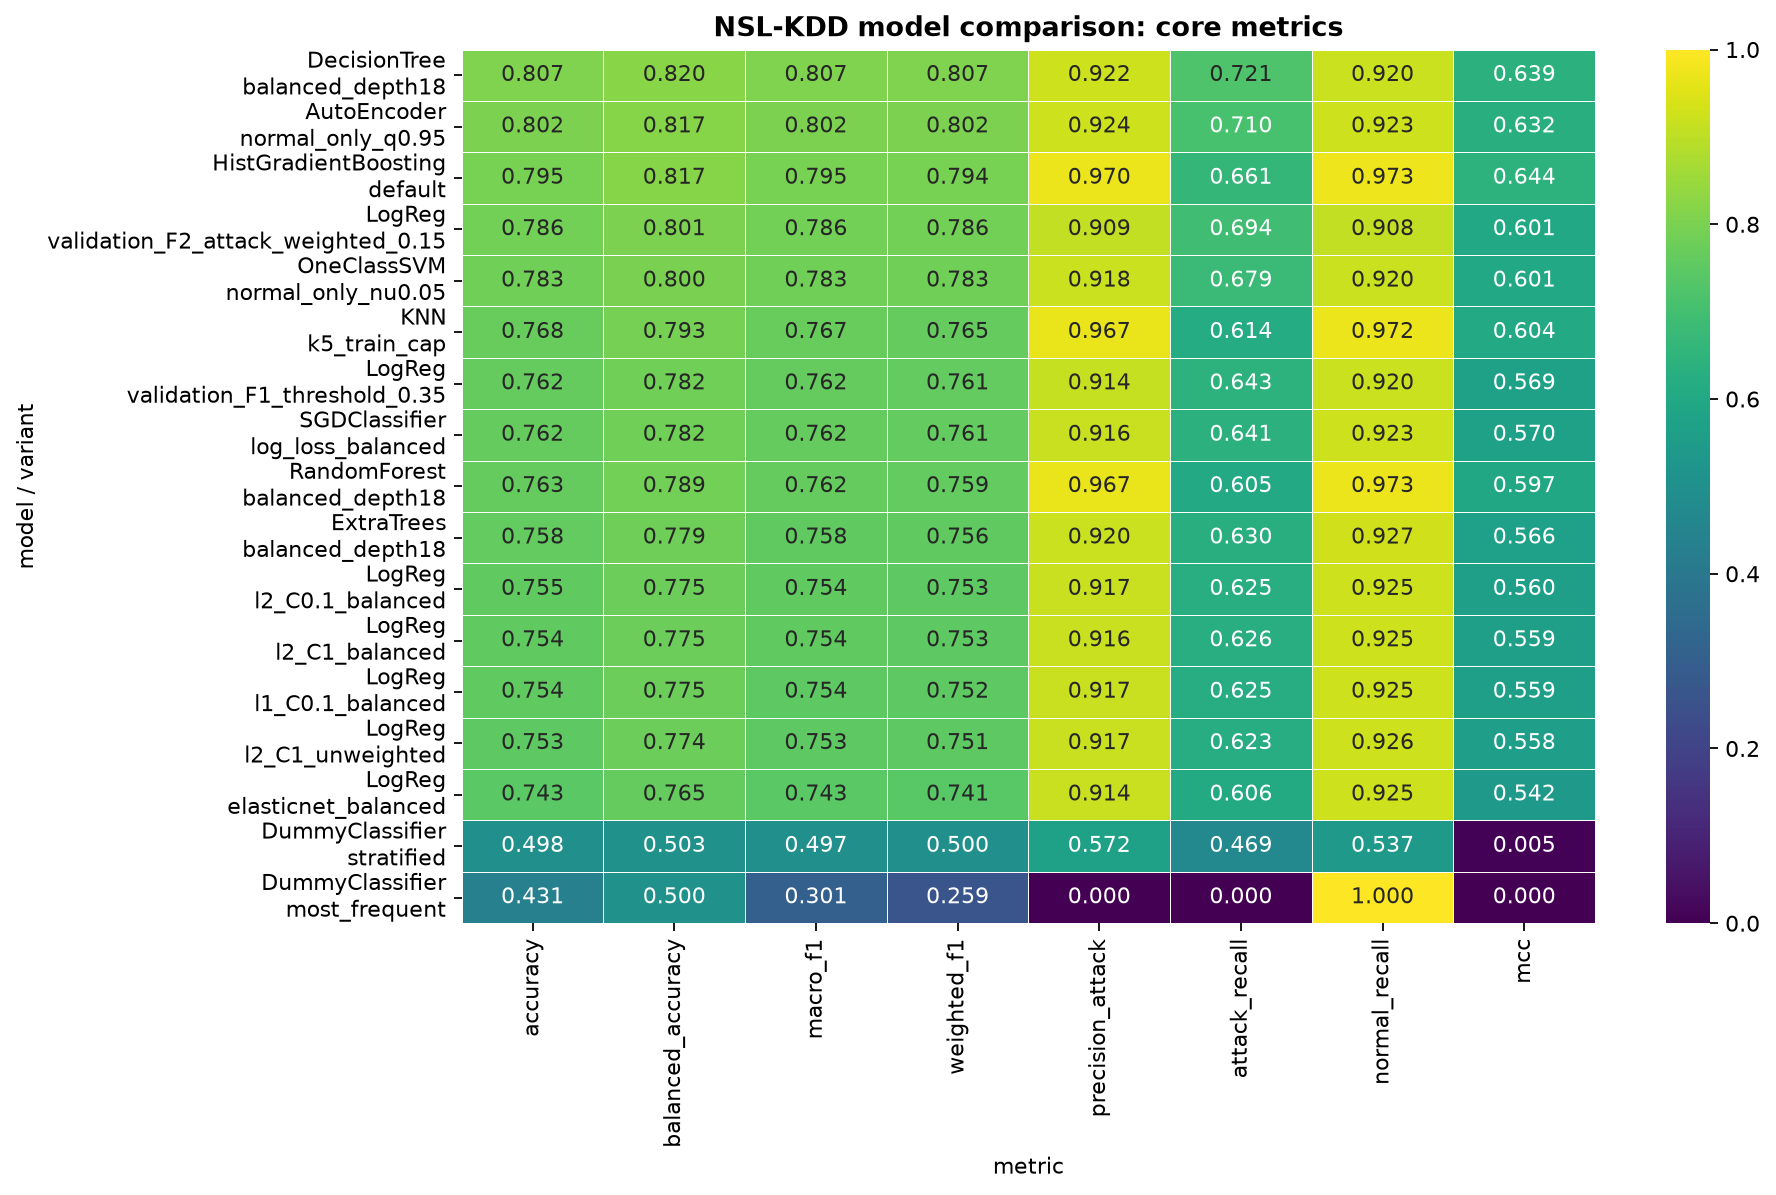

### nsl_macro_attack_scatter.png

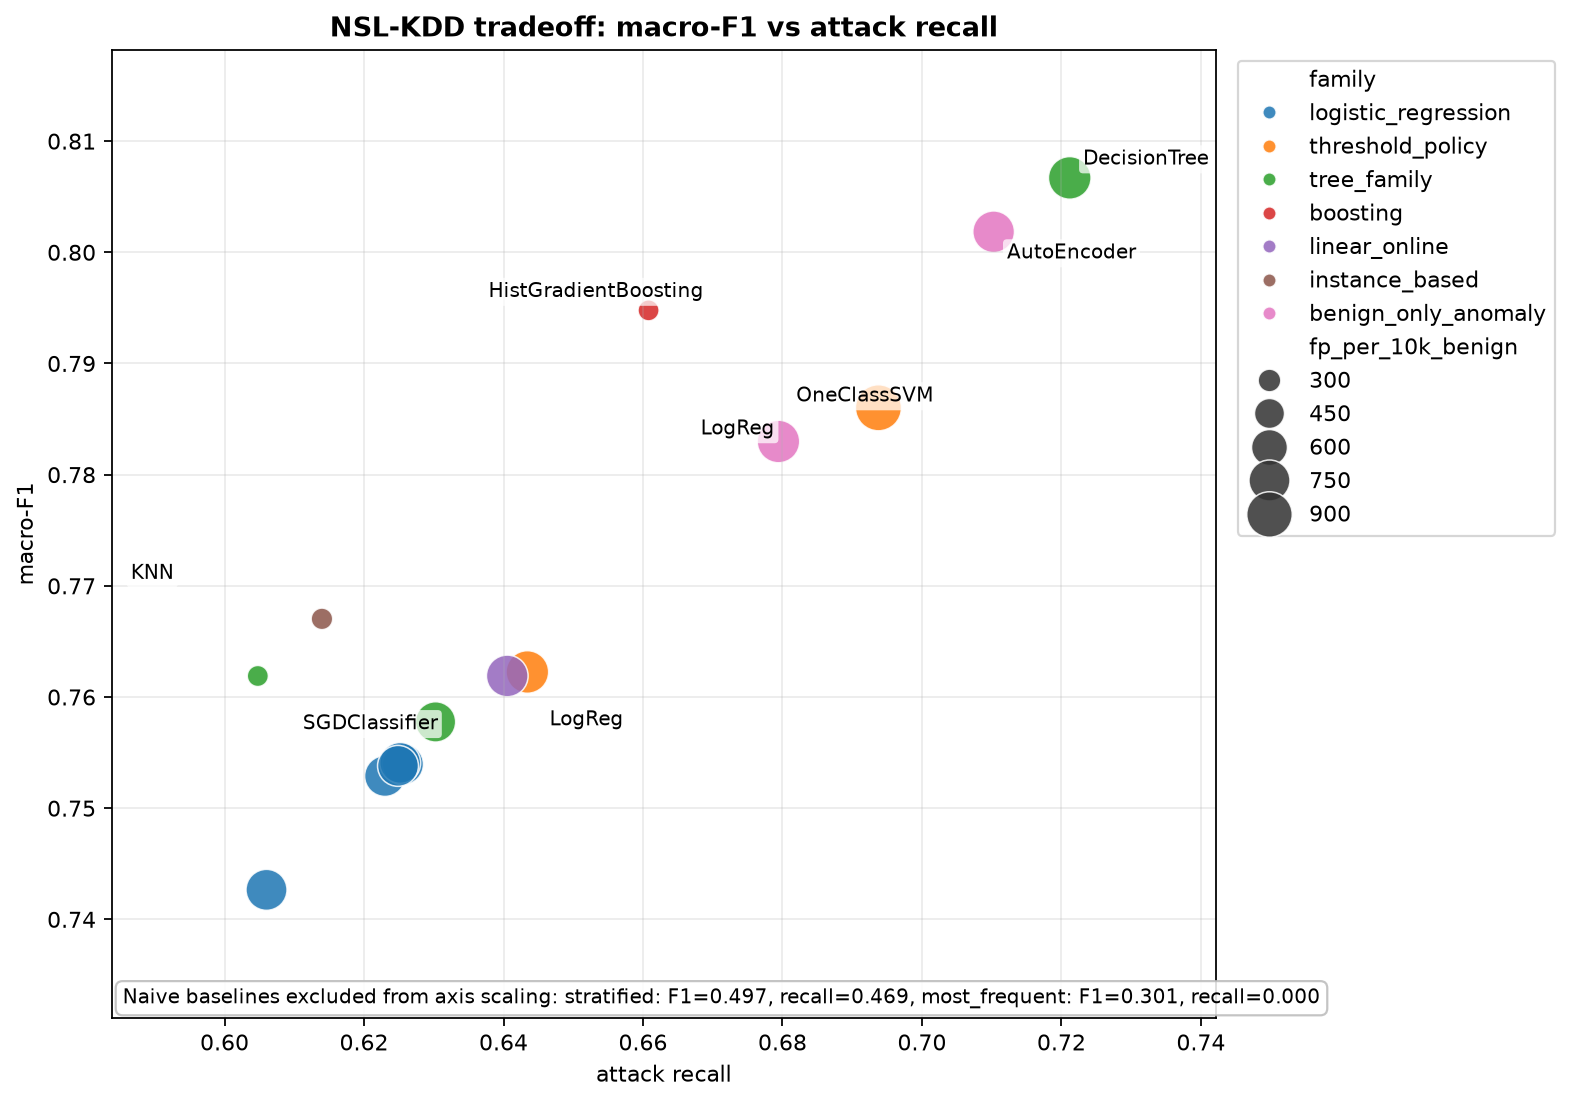

### nsl_feature_group_ablation_bars.png

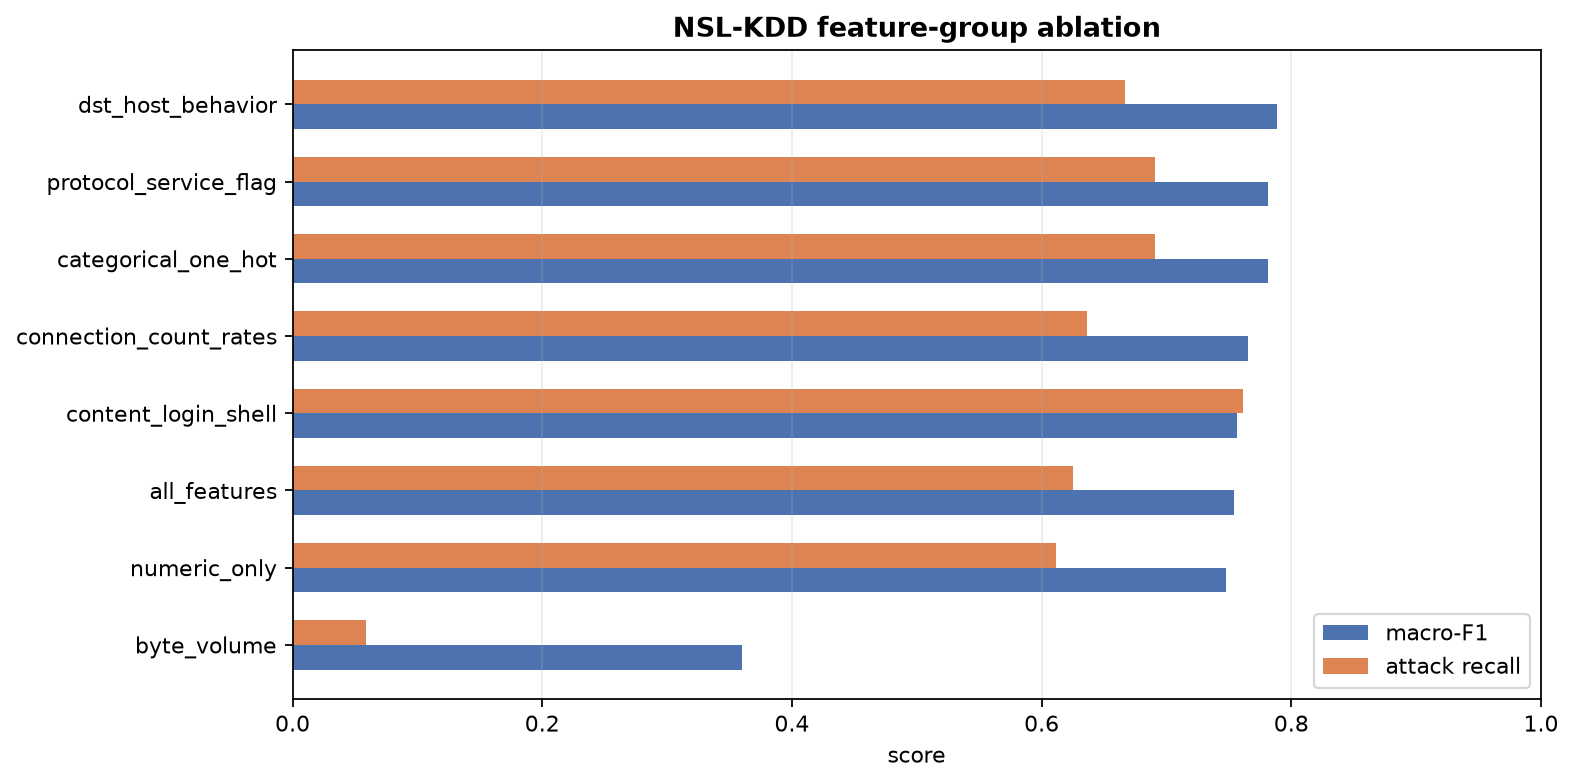

### nsl_bootstrap_confidence_intervals.png

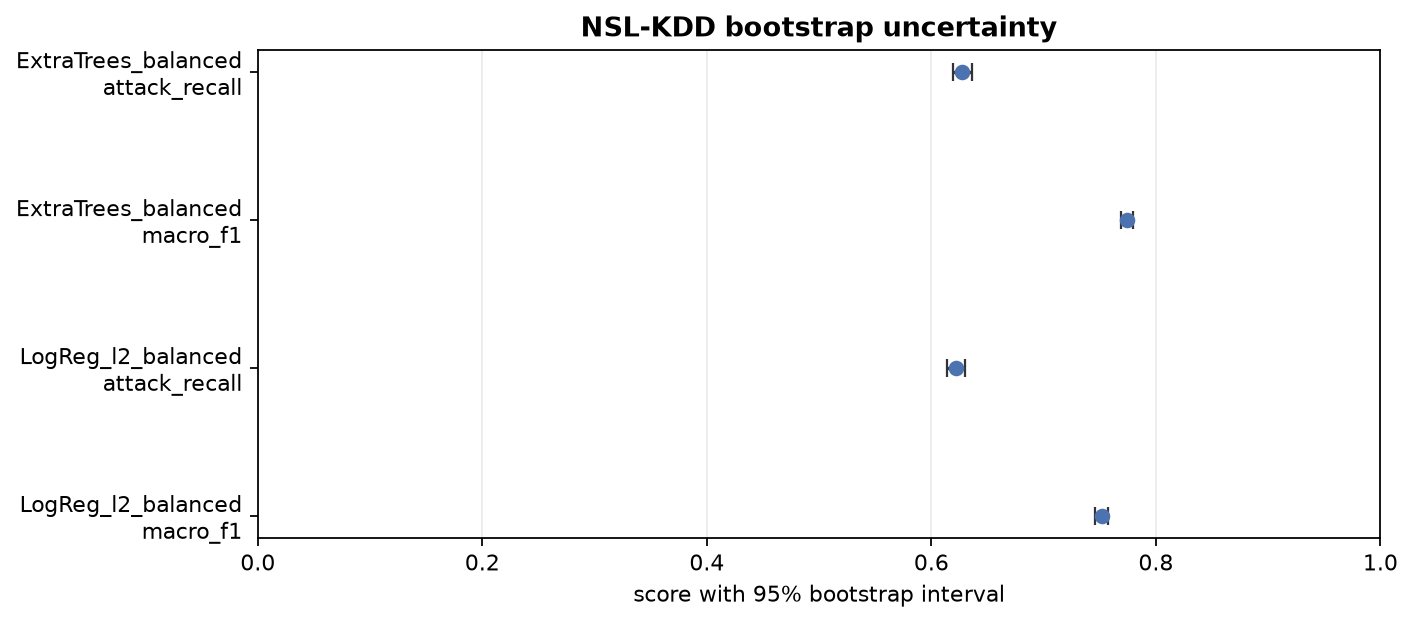

### nsl_attribute_consensus_top20.png

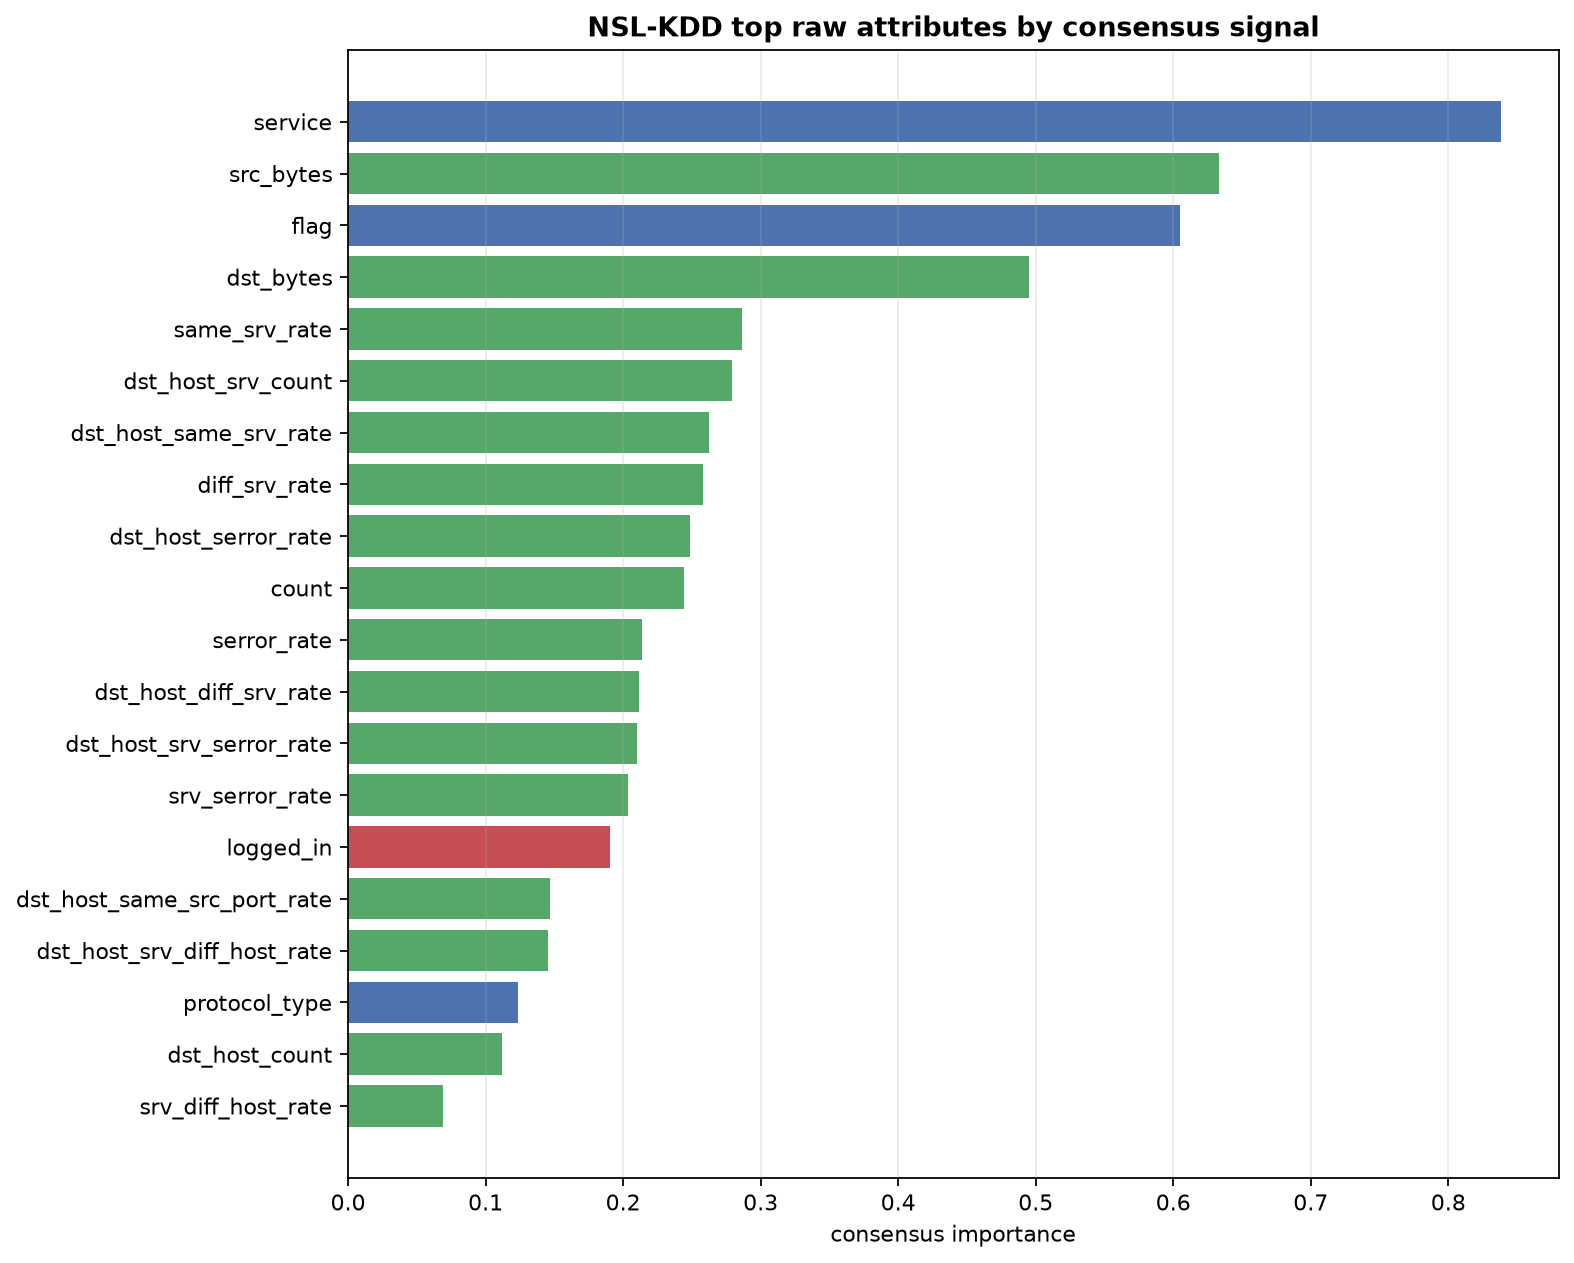

### nsl_threshold_tradeoff.png

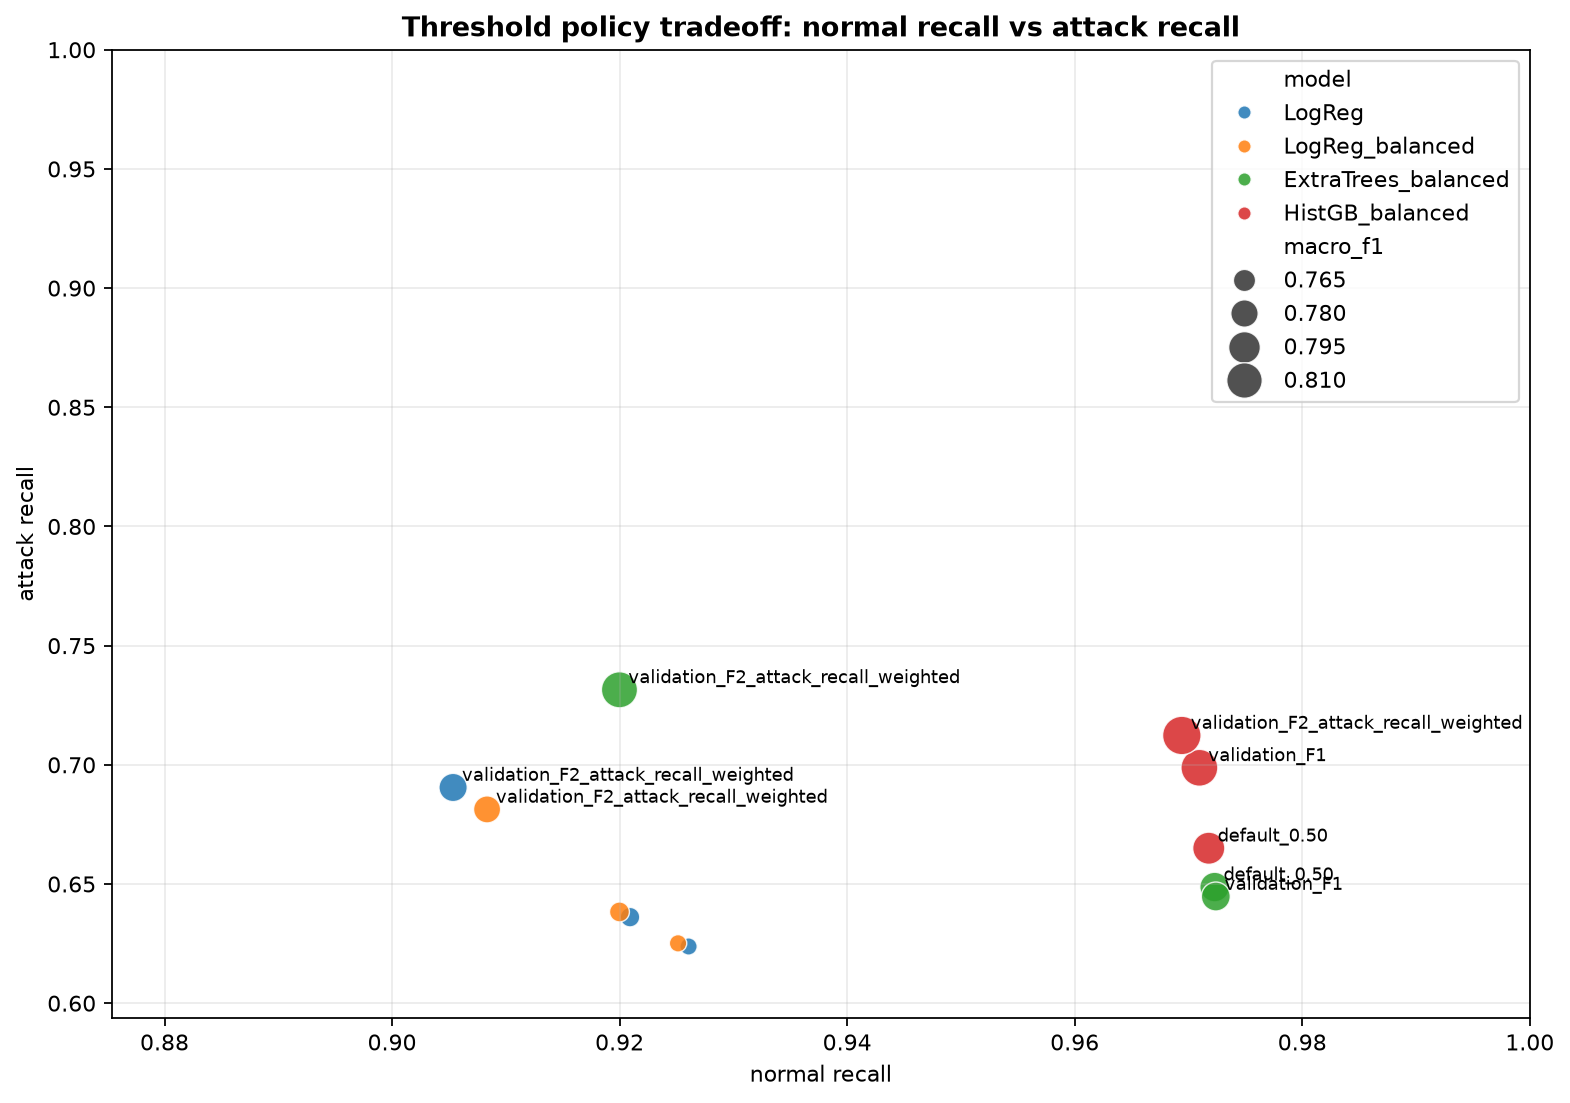

### nsl_concept_coverage_status.png

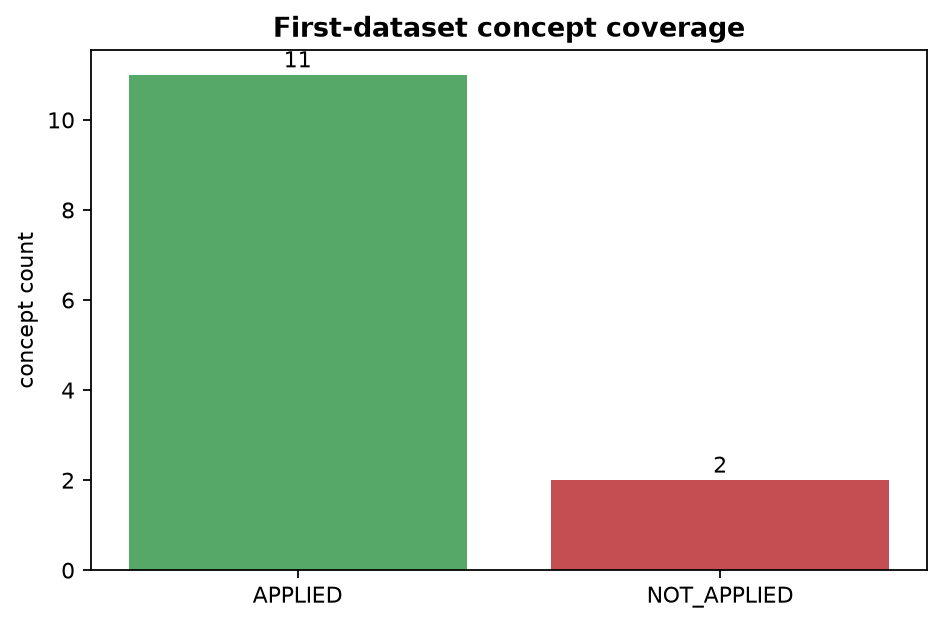

### nsl_outlier_score_distribution.png

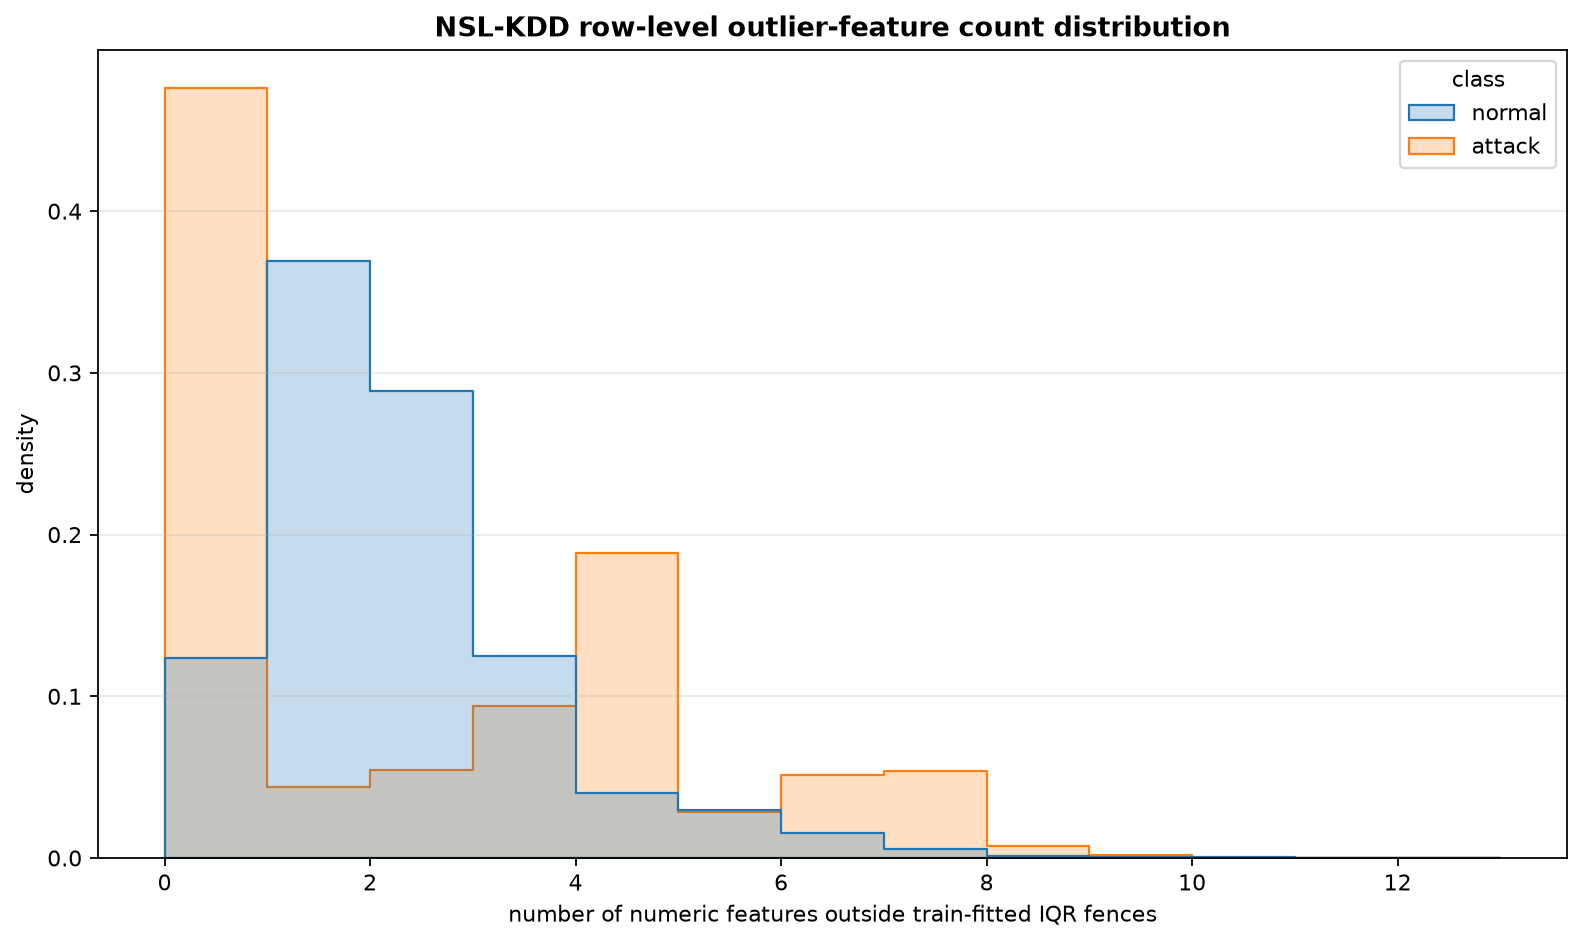

### nsl_top_outlier_datapoints.png

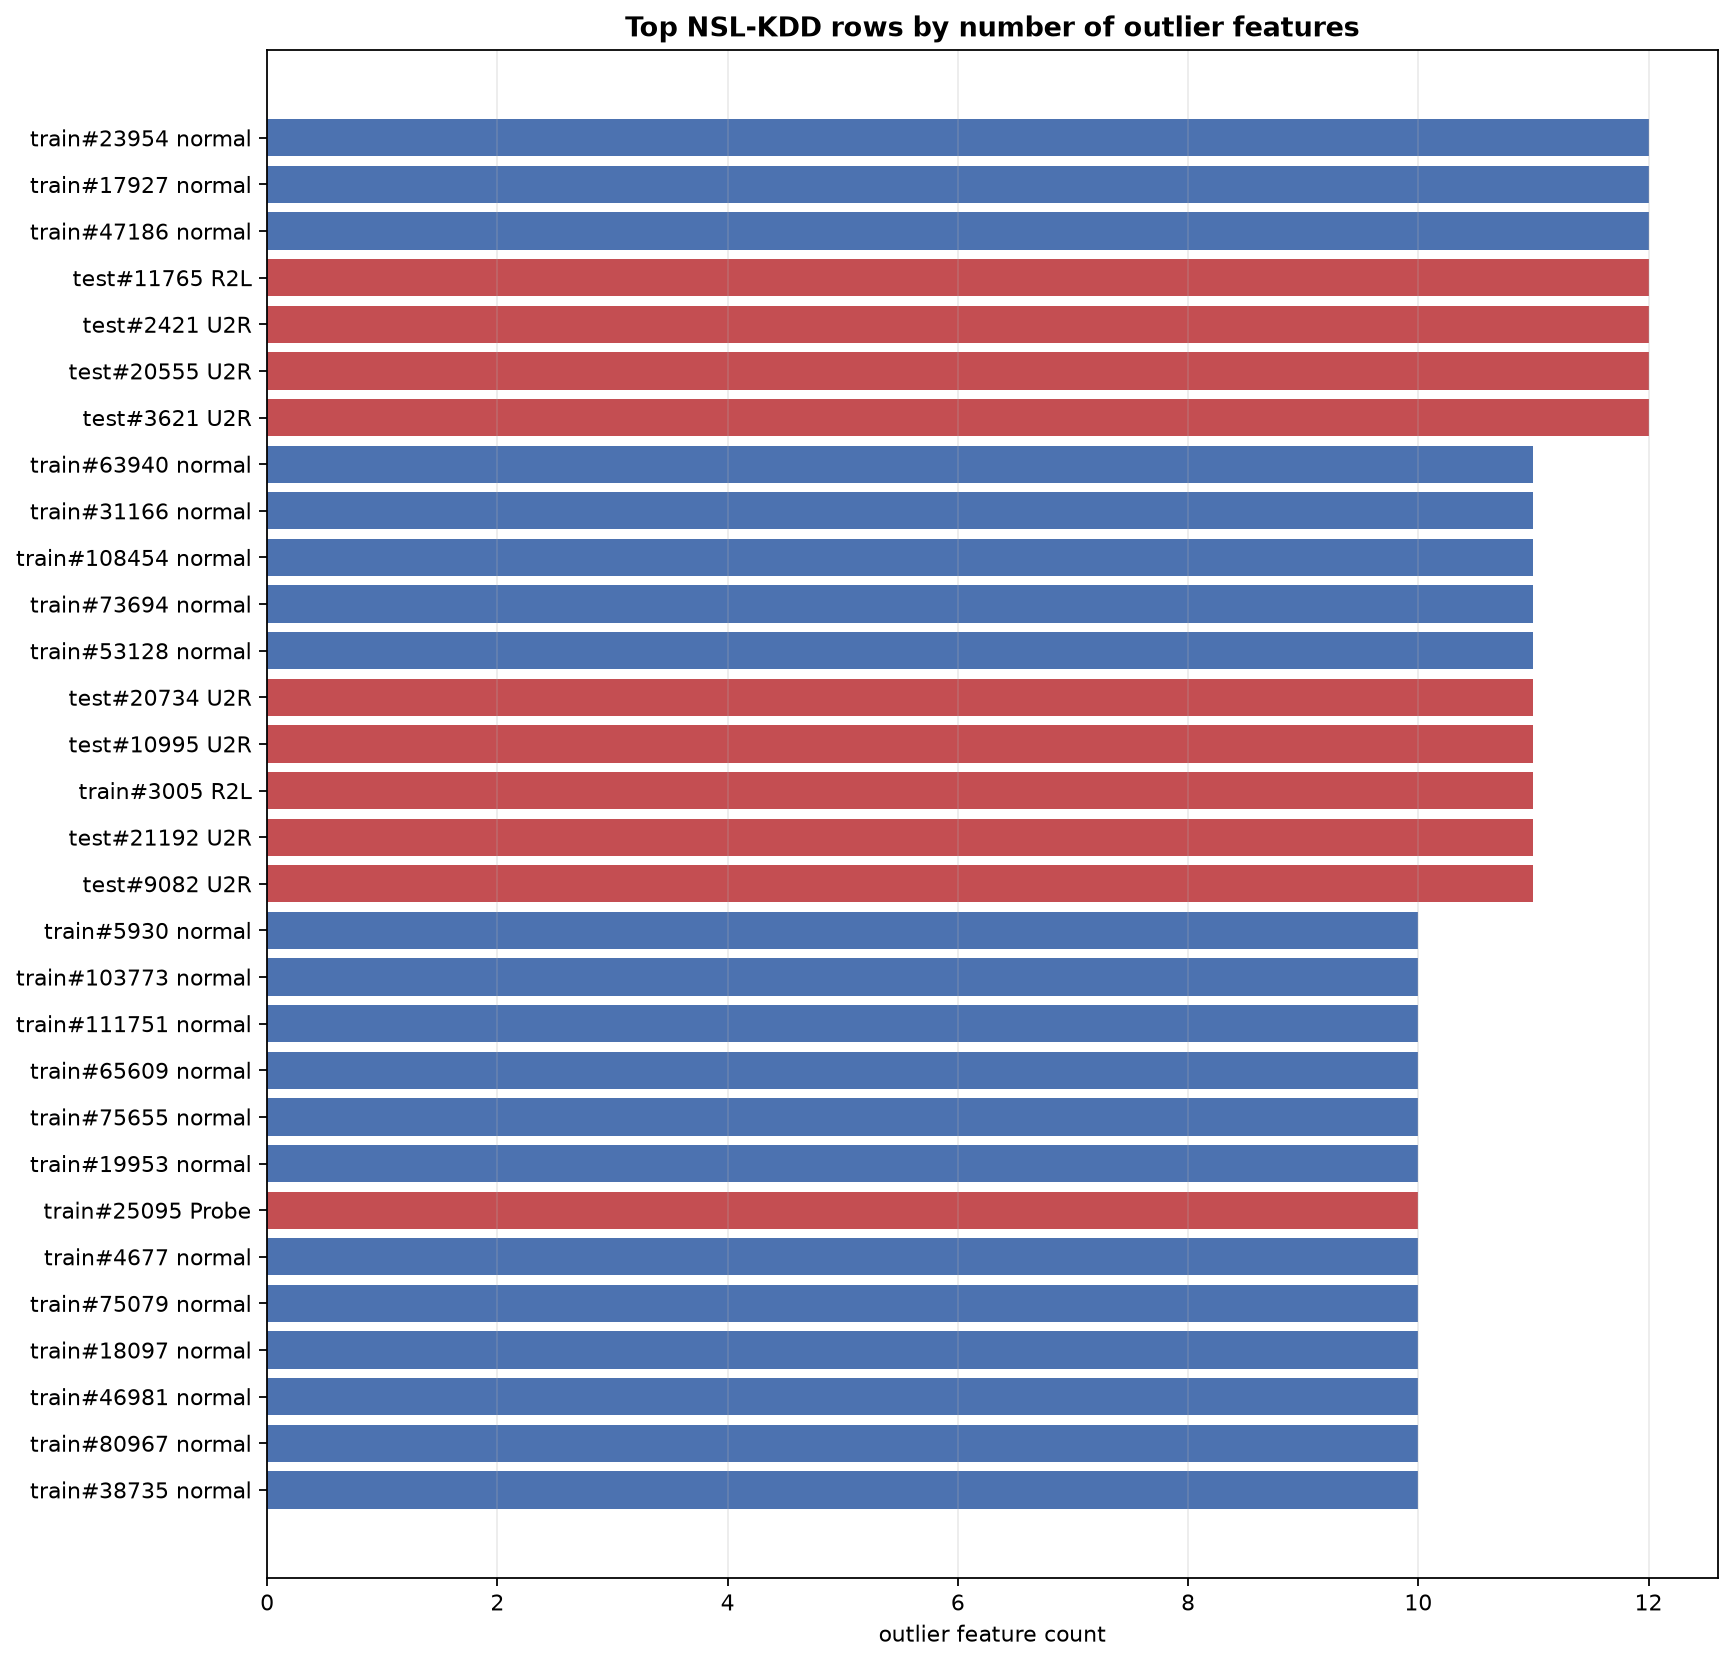

### nsl_top_outlier_feature_heatmap.png

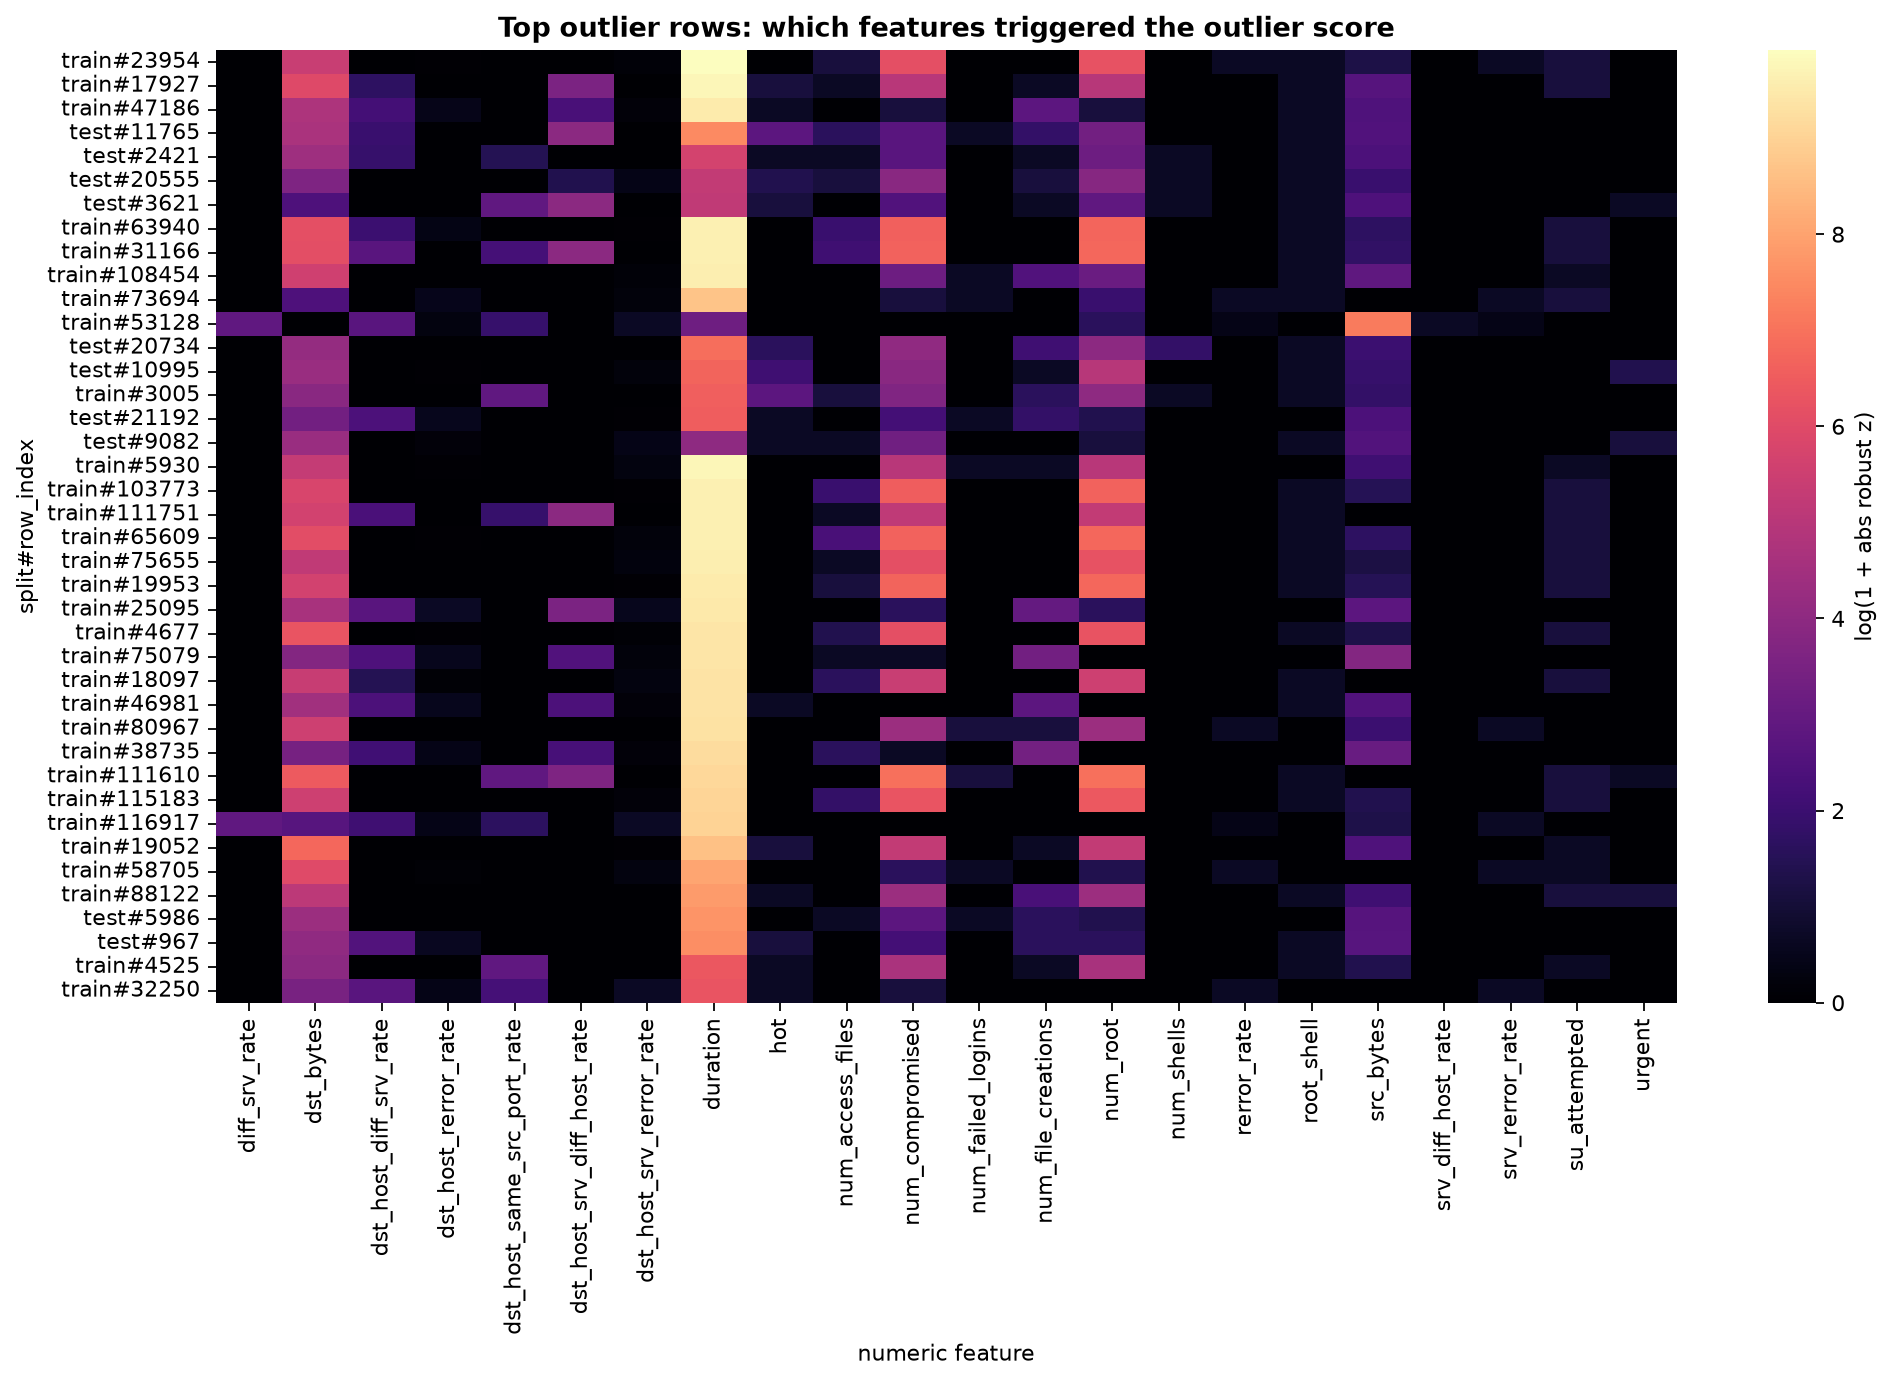

### nsl_outlier_feature_frequency.png

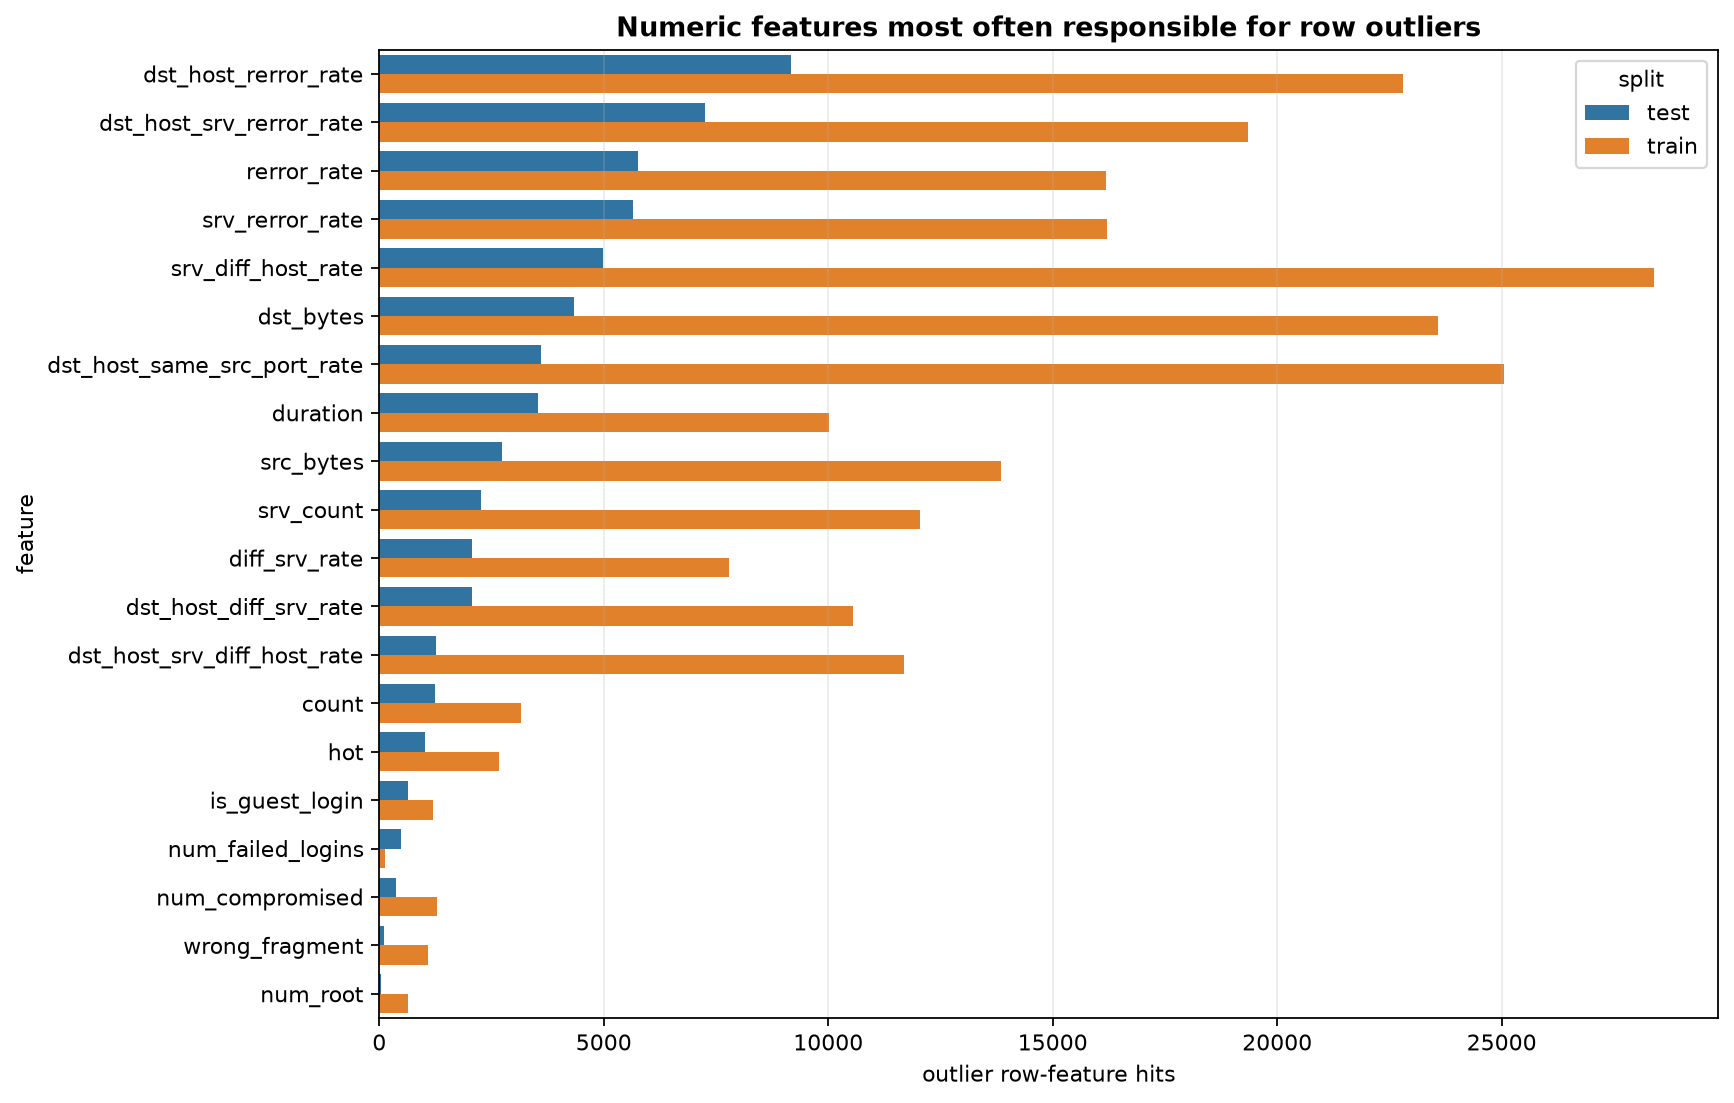

In [18]:
visual_summary = pd.read_csv(REPO / "results" / "visual_comparison_metric_summary.csv")
print("visual metric rows:", len(visual_summary))
visual_cols = [
    "source",
    "level",
    "family",
    "method",
    "variant",
    "macro_f1",
    "attack_recall",
    "precision_attack",
    "normal_recall",
    "mcc",
    "fp_per_10k_benign",
    "fn_per_10k_attack",
]
display(
    visual_summary.sort_values(["source", "macro_f1"], ascending=[True, False])
    [visual_cols]
    .head(30)
)

for image_path in [
    REPO / "results" / "figures" / "nsl_metric_heatmap.png",
    REPO / "results" / "figures" / "nsl_macro_attack_scatter.png",
    REPO / "results" / "figures" / "nsl_feature_group_ablation_bars.png",
    REPO / "results" / "figures" / "nsl_bootstrap_confidence_intervals.png",
    REPO / "results" / "figures" / "nsl_attribute_consensus_top20.png",
    REPO / "results" / "figures" / "nsl_threshold_tradeoff.png",
    REPO / "results" / "figures" / "nsl_concept_coverage_status.png",
    REPO / "results" / "figures" / "nsl_outlier_score_distribution.png",
    REPO / "results" / "figures" / "nsl_top_outlier_datapoints.png",
    REPO / "results" / "figures" / "nsl_top_outlier_feature_heatmap.png",
    REPO / "results" / "figures" / "nsl_outlier_feature_frequency.png",
]:
    if image_path.exists():
        display(Markdown(f"### {image_path.name}"))
        display(Image(filename=str(image_path)))


### 17. Final Audit: What Is Proven, Partial, Missing?

This is the referee layer. It prevents us from claiming things that have not been executed.

Read this after every major change.

In [19]:
audit_text = (REPO / "docs" / "audits" / "experimental_lab_prompt_audit.md").read_text(encoding="utf-8")
# Show the executive verdict and currently proven combinations.
start = audit_text.index("## Executive Verdict")
end = audit_text.index("## Requested Lab Matrix")
display(Markdown(audit_text[start:end]))


## Executive Verdict

- Proven areas: **12**
- Partial areas: **9**
- Missing areas: **3**
- Test files present: **15**
- Saved figures present: **43**
- Referee audit notebook outputs: **28 / 28 code cells**
- CICIoT2023 Phase-1 notebook outputs: **8 / 8 code cells**
- New threshold ablation: **True**
- New anomaly-detection report: **True**
- New semi-supervised report: **True**
- New SOC simulation: **True**
- New feature-learning report: **True**
- New deep-learning taxonomy: **True**
- New neural foundation report: **True**
- New neural ablation report: **True**

The project is now more than a supervised NSL-KDD comparison: it has saved threshold-tuning, normal-only anomaly, semi-supervised, online-proxy, and SOC-simulation artifacts. It is still **not yet** the full experimental lab: true temporal drift, graph ML, modern raw-dataset modelling, and cross-dataset generalization remain blocked by missing local data/schema work.

## Currently Proven Combinations

| Dataset | Track | Task/split combinations | Models/methods | Evidence |
| --- | --- | --- | --- | --- |
| NSL-KDD | Supervised reference | binary + multiclass | Dummy, balanced LogReg, balanced RF, balanced ExtraTrees, balanced HistGB, balanced LightGBM | 12 model/task rows in results/reference_track.md |
| NSL-KDD | Phase-3 official-split baseline | binary KDDTest+, binary KDDTest-21, multiclass KDDTest+ | RandomForest + LightGBM with train-only GridSearchCV | 6 evaluation rows plus confusion/ROC/PR/importance figures |
| NSL-KDD | Threshold tuning | binary KDDTest+ | LogReg, balanced LogReg, balanced ExtraTrees, balanced HistGB x default/F1/F2 thresholds | results/threshold_ablation.md and results/threshold_ablation.csv |
| NSL-KDD | Normal-only anomaly detection | binary plus attack-family recall | IsolationForest, LocalOutlierFactor, k-means distance x 0.90/0.95/0.99 normal quantiles | results/anomaly_detection.md and results/anomaly_detection.csv |
| NSL-KDD | Semi-supervised label budget | binary x 1/5/10/25% labels | labelled-only Logistic Regression vs self-training Logistic Regression | results/semi_supervised.md and results/semi_supervised.csv |
| NSL-KDD | Online-learning proxy | binary x file-order chunks | SGD log-loss partial_fit, SGD passive-aggressive-style partial_fit | results/online_learning.md; not a true drift claim |
| NSL-KDD | Operational SOC simulation | 1M daily flows, 0.5% malicious | threshold-ablation rates converted to alerts/misses/workload | results/soc_simulation.md and results/soc_simulation.csv |
| NSL-KDD | Feature analysis and representation learning | binary KDDTest+ | correlation/outlier maps; raw vs MI top-k vs PCA vs L1 vs autoencoder embeddings | results/feature_learning.md plus feature CSVs and figures |
| NSL-KDD | Neural foundations and MLP ablations | binary KDDTest+; bounded train subset | single-neuron demo; activation functions; MLP activation/dropout/norm/depth/loss/label-smoothing ablations | results/neural_foundations.md, results/neural_ablation.md, experiments/runs/neural_ablation.jsonl |
| NSL-KDD | Phase-4 MLP ablation | binary + multiclass | MLP unweighted vs weighted | 4 headline rows in results/metrics.md plus stability rows |
| NSL-KDD | Multi-seed stability | binary + multiclass x 5 seeds | RandomForest, LightGBM, MLP-unweighted, MLP-weighted | 40 train/evaluate runs summarized in results/stability.md |
| CICIoT2023 | Dev feature analysis and representation learning | binary dev split sample | correlation/outlier maps; raw vs MI top-k vs PCA vs L1 vs autoencoder embeddings | results/feature_learning.md caveated as dev sample only |
| CICIoT2023 | Dev data-quality track | train.parquet + test.parquet | quality/leakage checks in src/ciciot.py | 2 parquet files present |
| CICIoT2023 | Raw CSV Phase-1 track | CSV sample per file | label/category mapper and sample EDA notebook | 0 raw CSV files present; full raw audit blocked if zero |



### 18. What You Should Conclude Right Now

Concrete findings from the current NSL-KDD lab:

- The row-level outlier section now identifies exact train/test row indices, labels, attack families, and numeric features responsible for outlier flags.
- The visual dashboard now exposes model tradeoffs, metric heatmaps, feature-group effects, bootstrap uncertainty, threshold policy movement, and attribute importance as figures, not only tables.
- The NSL-KDD first-dataset learning lab now explicitly applies naive baselines, Logistic Regression variants, regularization, tree/ensemble baselines, feature-group ablations, bootstrap CIs, One-Class SVM, and benign-only autoencoder anomaly detection to the initial dataset.
- The attribute-by-attribute table is the main feature audit: it explains which raw attributes carry signal, which are redundant, which drift, and which need cautious engineering.
- The consolidated comparison table is the main referee object: it shows that macro-F1, attack recall, and SOC alert burden select different winners.
- One-hot + scaling turns 41 raw features into 122 model features.
- Rare classes are the hard part, not overall accuracy.
- Feature learning is mixed: PCA compressed variance but did not beat raw features; autoencoder embeddings slightly improved the simple classifier in the saved run.
- In bounded MLP ablations, label smoothing helped more than simply making the network deeper.
- Threshold tuning changes the attack-recall vs false-alert trade-off.
- Anomaly detection gives a genuinely different lens, but it is not automatically better than supervised classification.
- Self-training did not beat labelled-only Logistic Regression in the saved semi-supervised run.
- CNN/RNN/GAN/DRL are not “next because fancy”; they need valid sequence, packet, matrix, or environment representations first.

The next serious stage should be either:

1. calibration + explainability for the binary models, or
2. true temporal/window construction on a timestamped dataset, or
3. raw CICIoT2023 CSV ingestion once the official files are present.